# eBATTLE Clinical Study — Data Science Thesis Analysis

Applies a wearable-to-prediction pipeline to pilot data from the eBATTLE Obesity trial: raw Garmin CSVs → preprocessing → feature engineering → activity target prediction.

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy import stats
from scipy.stats import pointbiserialr

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, brier_score_loss,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve  # AUPRC — recommended for small imbalanced datasets
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print('XGBoost available ✓')
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — running 3 classifiers')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded ✓')

XGBoost available ✓
Libraries loaded ✓


In [2]:
DATA_ROOT  = Path('/Users/mission/usn/thesis/v3/Data')
OUTPUT_DIR = Path('/Users/mission/usn/thesis/v3/results_thesis')
OUTPUT_DIR.mkdir(exist_ok=True)

PILOT_DIRS = {
    1: DATA_ROOT / 'pilot_utrekk1_271125',
    2: DATA_ROOT / 'pilot_utrekk2_271125',
}

PHASE1_DAYS = (0,  13)   # first 2 weeks  (days 0–13)
PHASE2_DAYS = (14, 41)   # following 4 weeks (days 14–41)

COL_MAP = {
    'User Id'                  : 'user_id',
    'Calendar Date (Local)'    : 'date',
    'Wearing Time (%)'         : 'wear_pct',
    'Calories (kcal)'          : 'kcal',
    'Steps'                    : 'steps',
    'Floors Climbed'           : 'floors',
    'Distance (m)'             : 'distance_m',
    'Mean Motion Intensity'    : 'motion_intensity',
    'MET (avg)'                : 'met_avg',
    'MVPA (mins)'              : 'mvpa_min',
    'Active Sec (s)'           : 'active_s',
    'Stress (avg)'             : 'stress_mean',
    'Body Battery (avg)'       : 'body_battery_avg',
    'Awake Duration (s)'       : 'sleep_awake_s',
    'Light Sleep Duration (s)' : 'sleep_light_s',
    'Deep Sleep Duration (s)'  : 'sleep_deep_s',
    'Rem Sleep Duration (s)'   : 'sleep_rem_s',
    'RMSSD'                    : 'rmssd_ms',
    'Heart Rate (min)'         : 'hr_min',
    'Heart Rate (avg)'         : 'hr_mean',
    'Heart Rate (max)'         : 'hr_max',
    'Resting Heart Rate (avg)' : 'rhr_mean',
    'Pulse Ox (avg)'           : 'spo2_mean',
    'Respiration-Rate (avg)'   : 'resp_mean',
    'Skin Temperature (avg)'   : 'skin_temp_avg',
    'SDNN'                     : 'sdnn_ms',
}

# Excluded from PHYSIOL_COLS (insufficient data coverage in both pilot cohorts):
#   rmssd_ms, sdnn_ms: 0% coverage (HRV not exported by Garmin Connect)
#   skin_temp_avg: 0% coverage (sensor absent on device models used)
#   spo2_mean: 6.6% coverage — drops at 30% missingness filter
PHYSIOL_COLS = [
    'hr_mean', 'hr_min', 'hr_max', 'rhr_mean',
    'stress_mean', 'resp_mean',
    'body_battery_avg',
    'sleep_awake_s', 'sleep_light_s', 'sleep_deep_s', 'sleep_rem_s',
    'motion_intensity', 'met_avg', 'active_s',
    'baseline_bmi', 'baseline_body_fat_pct', 'baseline_weight_kg',  # static per-patient (Pilot 1 only; NaN-imputed for others)
]
ACTIVITY_COLS = ['steps', 'mvpa_min', 'kcal', 'distance_m', 'floors']
ALL_SIGNAL_COLS = PHYSIOL_COLS + ACTIVITY_COLS

TARGETS = {
    # WHO (2020) Global guidelines on physical activity — children/adolescents 5–17: 60 min/day
    'mvpa_420': {'col': 'mvpa_sum', 'threshold': 420, 'label': 'MVPA ≥420 min/wk (WHO paediatric)'},
    # WHO (2019) adult guideline — retained as adult comparison point only
    'mvpa_150': {'col': 'mvpa_sum', 'threshold': 150, 'label': 'MVPA ≥150 min/wk (WHO adult ref)'},
}

PRIMARY_TARGET   = 'mvpa_420'   # WHO paediatric guideline — Section 1.7
HOLD_OUT_FRAC    = 0.20         # 20% of patients held out — never touched until Act 3
CV_FOLDS         = 3
RANDOM_SEED      = 42
MIN_VALID_DAYS   = 3
MIN_WEAR_PCT     = 60.0
MAX_MISSING_FRAC = 0.30
MAX_CORR         = 0.95

print('Configuration loaded ✓')
print(f'Phase 1: days {PHASE1_DAYS}  ({PHASE1_DAYS[1]//7 + 1} weeks)')
print(f'Phase 2: days {PHASE2_DAYS}  ({(PHASE2_DAYS[1] - PHASE2_DAYS[0])//7 + 1} weeks, starts week 3)')
print(f'Hold-out fraction: {HOLD_OUT_FRAC:.0%} of patients')
print(f'Primary target: {PRIMARY_TARGET}  (WHO paediatric: ≥420 min/wk)')
print(f'Physiological signals for ML: {len(PHYSIOL_COLS)}')
print(f'  Excluded (0–7% coverage): rmssd_ms, sdnn_ms, skin_temp_avg, spo2_mean')


Configuration loaded ✓
Phase 1: days (0, 13)  (2 weeks)
Phase 2: days (14, 41)  (4 weeks, starts week 3)
Hold-out fraction: 20% of patients
Primary target: mvpa_420  (WHO paediatric: ≥420 min/wk)
Physiological signals for ML: 17
  Excluded (0–7% coverage): rmssd_ms, sdnn_ms, skin_temp_avg, spo2_mean


---
## Act 1 — Setup

## 1.1 Research Question

Predicts whether an adolescent obesity patient will meet their physical activity target (MVPA ≥ 420 min/week) in the coming week using continuously monitored wearable signals.

- **H₀**: Wearable signals achieve AUC < 0.70 on the hold-out set for the primary target.
- **H₁**: At least one model achieves AUC ≥ 0.70 on the hold-out set.

In [3]:
hypothesis = {
    'H0': 'Physiological wearable signals do not achieve clinically acceptable discrimination for next-week physical activity performance (AUC < 0.70 for all models on the hold-out set)',
    'H1': 'At least one model achieves AUC ≥ 0.70 on the hold-out set for the primary target (mvpa_420)',
    'acceptance_threshold': {
        'roc_auc_min'  : 0.70,   # Hosmer & Lemeshow (2000): acceptable discrimination
        'roc_auc_good' : 0.80,   # good discrimination
        'brier_max'    : 0.20,   # calibration: acceptable probability reliability
    },
    'primary_target': PRIMARY_TARGET,
    'prediction_horizon': '1 week ahead',
    'validation_strategy': 'Patient-level hold-out (20%) + 3-fold StratifiedGroupKFold on train set',
}

print('=== Hypothesis ===')
for k, v in hypothesis.items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'    {kk}: {vv}')
    else:
        print(f'  {k}: {v}')

=== Hypothesis ===
  H0: Physiological wearable signals do not achieve clinically acceptable discrimination for next-week physical activity performance (AUC < 0.70 for all models on the hold-out set)
  H1: At least one model achieves AUC ≥ 0.70 on the hold-out set for the primary target (mvpa_420)
  acceptance_threshold:
    roc_auc_min: 0.7
    roc_auc_good: 0.8
    brier_max: 0.2
  primary_target: mvpa_420
  prediction_horizon: 1 week ahead
  validation_strategy: Patient-level hold-out (20%) + 3-fold StratifiedGroupKFold on train set


## 1.2 Dataset

Loads data from two pilot cohorts of the eBATTLE trial. The primary source is `daily-health-log.csv` — a pre-aggregated file covering all Garmin sensor signals per user per calendar day.

In [4]:
frames = []
dataset_stats = []

for pilot_id, pilot_dir in PILOT_DIRS.items():
    fpath = pilot_dir / 'daily-health-log.csv'
    if not fpath.exists():
        print(f'WARNING: {fpath} not found')
        continue
    df = pd.read_csv(fpath, low_memory=False)
    df['pilot'] = pilot_id
    frames.append(df)

    date_col = 'Calendar Date (Local)'
    dataset_stats.append({
        'Pilot'      : pilot_id,
        'Rows'       : f"{len(df):,}",
        'Users'      : df['User Id'].nunique(),
        'Columns'    : len(df.columns),
        'Date start' : df[date_col].min() if date_col in df.columns else 'N/A',
        'Date end'   : df[date_col].max() if date_col in df.columns else 'N/A',
    })

raw = pd.concat(frames, ignore_index=True)

print('=== Raw Dataset Overview ===')
print(pd.DataFrame(dataset_stats).to_string(index=False))
print(f'\nCombined : {len(raw):,} rows  |  {raw["User Id"].nunique()} unique users  |  {raw.shape[1]} columns')
print(f'\nNote: Each row = 1 user × 1 calendar day (pre-aggregated by Garmin Connect)')

=== Raw Dataset Overview ===
 Pilot   Rows  Users  Columns Date start   Date end
     1 16,240     28       74 2024-01-01 2025-08-01
     2  4,200      7       74 2024-01-01 2025-08-21

Combined : 20,440 rows  |  35 unique users  |  74 columns

Note: Each row = 1 user × 1 calendar day (pre-aggregated by Garmin Connect)


In [5]:
groups = {
    'Identity'        : ['User Id', 'Calendar Date (Local)', 'Time Zone (Local)'],
    'Wear / Duration' : ['Wearing Time (%)', 'Duration (s)'],
    'Activity'        : ['Steps', 'MVPA (mins)', 'Calories (kcal)', 'Distance (m)', 'Floors Climbed'],
    'Heart Rate'      : ['Heart Rate (avg)', 'Heart Rate (min)', 'Heart Rate (max)', 'Resting Heart Rate (avg)'],
    'HRV'             : ['RMSSD', 'SDNN', 'BBI (avg)'],
    'Stress'          : ['Stress (avg)', 'Body Battery (avg)'],
    'Sleep'           : ['Deep Sleep Duration (s)', 'Light Sleep Duration (s)', 'Rem Sleep Duration (s)', 'Awake Duration (s)'],
    'SpO2 / Resp'     : ['Pulse Ox (avg)', 'Respiration-Rate (avg)'],
    'Temperature'     : ['Skin Temperature (avg)'],
    'MET / Intensity' : ['MET (avg)', 'Mean Motion Intensity'],
}

print('Column groups in daily-health-log.csv:')
for grp, cols in groups.items():
    available = [c for c in cols if c in raw.columns]
    print(f'  {grp:<20} {available}')

print(f'\nTotal columns in file: {len(raw.columns)}')
print(f'Columns we use       : {len(COL_MAP)}')

Column groups in daily-health-log.csv:
  Identity             ['User Id', 'Calendar Date (Local)', 'Time Zone (Local)']
  Wear / Duration      ['Wearing Time (%)', 'Duration (s)']
  Activity             ['Steps', 'MVPA (mins)', 'Calories (kcal)', 'Distance (m)', 'Floors Climbed']
  Heart Rate           ['Heart Rate (avg)', 'Heart Rate (min)', 'Heart Rate (max)', 'Resting Heart Rate (avg)']
  HRV                  ['RMSSD', 'SDNN', 'BBI (avg)']
  Stress               ['Stress (avg)', 'Body Battery (avg)']
  Sleep                ['Deep Sleep Duration (s)', 'Light Sleep Duration (s)', 'Rem Sleep Duration (s)', 'Awake Duration (s)']
  SpO2 / Resp          ['Pulse Ox (avg)', 'Respiration-Rate (avg)']
  Temperature          ['Skin Temperature (avg)']
  MET / Intensity      ['MET (avg)', 'Mean Motion Intensity']

Total columns in file: 74
Columns we use       : 26


## 1.3 Data Preprocessing

Replaces sensor-zero artefacts with NaN, enforces physiological plausibility ranges, excludes days with less than 60% device wear time, and builds a clean daily panel.

=== Missing data in signal columns ===

Column                                 Missing %
--------------------------------------------------
SDNN                                      100.0% ← >30% threshold
Skin Temperature (avg)                    100.0% ← >30% threshold
RMSSD                                     100.0% ← >30% threshold
Pulse Ox (avg)                             99.6% ← >30% threshold
Light Sleep Duration (s)                   96.3% ← >30% threshold
Rem Sleep Duration (s)                     96.3% ← >30% threshold
Deep Sleep Duration (s)                    96.3% ← >30% threshold
Awake Duration (s)                         96.3% ← >30% threshold
Respiration-Rate (avg)                     94.6% ← >30% threshold
Resting Heart Rate (avg)                   94.1% ← >30% threshold
Heart Rate (max)                           94.1% ← >30% threshold
Heart Rate (avg)                           94.1% ← >30% threshold
Heart Rate (min)                           94.1% ← >30% threshold
ME

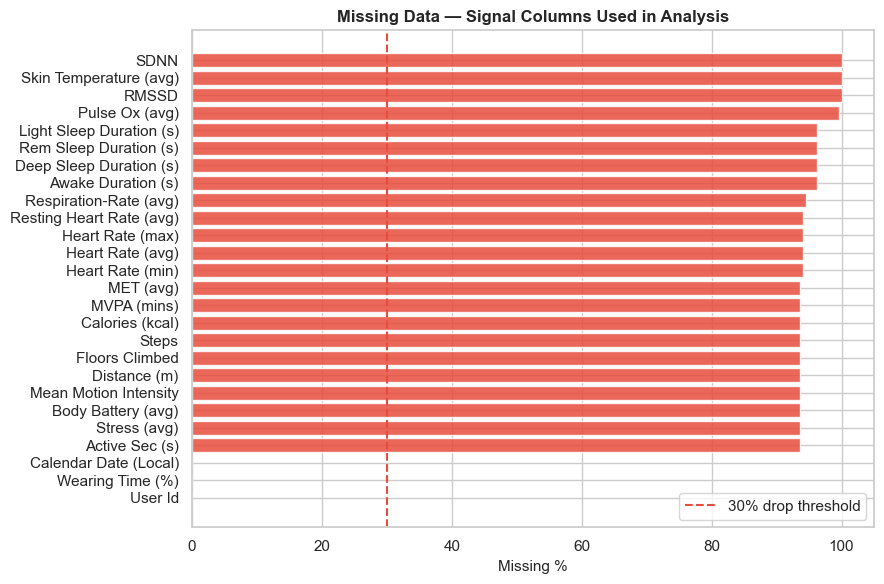


Columns >30% missing (dropped in feature selection): 23
Columns ≤30% missing (retained):                    3


In [6]:
use_cols_raw = list(COL_MAP.keys())
use_cols_in_file = [c for c in use_cols_raw if c in raw.columns]

null_pct = (raw[use_cols_in_file].isnull().sum() / len(raw) * 100).sort_values(ascending=False).round(1)

print('=== Missing data in signal columns ===\n')
print(f'{"Column":<35} {"Missing %":>12}')
print('-' * 50)
for col, pct in null_pct.items():
    flag = ' ← >30% threshold' if pct > 30 else ''
    print(f'{col:<35} {pct:>11.1f}%{flag}')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if p > 30 else '#3498db' for p in null_pct]
ax.barh(null_pct.index[::-1], null_pct.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(30, color='#e74c3c', linestyle='--', linewidth=1.5, label='30% drop threshold')
ax.set_xlabel('Missing %', fontsize=11)
ax.set_title('Missing Data — Signal Columns Used in Analysis', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'missing_data.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nColumns >30% missing (dropped in feature selection): {(null_pct > 30).sum()}')
print(f'Columns ≤30% missing (retained):                    {(null_pct <= 30).sum()}')

In [7]:

PLAUSIBILITY = {
    'Heart Rate (avg)'         : (30,  220),
    'Heart Rate (min)'         : (25,  220),
    'Heart Rate (max)'         : (30,  250),
    'Resting Heart Rate (avg)' : (25,  120),
    'Stress (avg)'             : (0,   100),
    'Pulse Ox (avg)'           : (70,  100),
    'Respiration-Rate (avg)'   : (4,    60),
    'Body Battery (avg)'       : (0,   100),
}

raw_clean = raw.copy()

outlier_report = []
for col, (lo, hi) in PLAUSIBILITY.items():
    if col not in raw_clean.columns:
        continue
    # Sensor-zero: HR == 0 means device not worn
    zero_mask  = raw_clean[col] == 0
    range_mask = ~raw_clean[col].between(lo, hi) & ~raw_clean[col].isna() & ~zero_mask
    raw_clean.loc[zero_mask | range_mask, col] = np.nan
    outlier_report.append({
        'Column'         : col,
        'Range'          : f'[{lo}, {hi}]',
        'Zeroes removed' : int(zero_mask.sum()),
        'Out-of-range'   : int(range_mask.sum()),
    })

print('=== Outlier / Artefact Removal ===')
print(pd.DataFrame(outlier_report).to_string(index=False))
print(f'\nNote: Zero HR values indicate device not worn — replaced with NaN, not 0.')
print(f'Treating 0 as a valid HR would produce a mean HR of ~60 bpm instead of ~85 bpm for this cohort.')
print(f'\nNot checked (0% coverage, excluded from ML): RMSSD, Skin Temperature (avg).')


=== Outlier / Artefact Removal ===
                  Column     Range  Zeroes removed  Out-of-range
        Heart Rate (avg) [30, 220]               4             0
        Heart Rate (min) [25, 220]               4             0
        Heart Rate (max) [30, 250]               4             0
Resting Heart Rate (avg) [25, 120]              50             0
            Stress (avg)  [0, 100]             127             0
          Pulse Ox (avg) [70, 100]               0             0
  Respiration-Rate (avg)   [4, 60]               3             0
      Body Battery (avg)  [0, 100]             293             3

Note: Zero HR values indicate device not worn — replaced with NaN, not 0.
Treating 0 as a valid HR would produce a mean HR of ~60 bpm instead of ~85 bpm for this cohort.

Not checked (0% coverage, excluded from ML): RMSSD, Skin Temperature (avg).


In [8]:

rename_actual = {k: v for k, v in COL_MAP.items() if k in raw_clean.columns}
panel = raw_clean.rename(columns=rename_actual).copy()

keep_cols = [v for v in COL_MAP.values() if v in panel.columns] + ['pilot']
panel = panel[keep_cols].copy()

panel['date'] = pd.to_datetime(panel['date'], errors='coerce').dt.tz_localize(None)
panel = panel.dropna(subset=['user_id', 'date'])

n_before = len(panel)
panel = panel[panel['wear_pct'] > 0].copy()
n_zero_wear_dropped = n_before - len(panel)
print(f'Dropped {n_zero_wear_dropped:,} zero-wear rows (wear_pct == 0)')

core_signals = [c for c in (PHYSIOL_COLS + ACTIVITY_COLS) if c in panel.columns]
null_frac_row = panel[core_signals].isnull().mean(axis=1)
n_before = len(panel)
panel = panel[null_frac_row <= 0.5].copy()
n_empty_dropped = n_before - len(panel)
print(f'Dropped {n_empty_dropped:,} rows where >50% of core signals were null')

panel['valid_wear_day'] = (panel['wear_pct'] >= MIN_WEAR_PCT).astype(int)

has_signal = panel[core_signals].notna().any(axis=1)
day1_map = panel[has_signal].groupby('user_id')['date'].min()
panel = panel[panel['user_id'].isin(day1_map.index)].copy()
panel['day1'] = panel['user_id'].map(day1_map)
panel['days_since_day1'] = (panel['date'] - panel['day1']).dt.days

def assign_phase(d):
    if PHASE1_DAYS[0] <= d <= PHASE1_DAYS[1]: return 'phase1'
    elif PHASE2_DAYS[0] <= d <= PHASE2_DAYS[1]: return 'phase2'
    elif d < PHASE1_DAYS[0]: return 'pre_trial'
    else: return 'post_trial'

panel['phase'] = panel['days_since_day1'].apply(assign_phase)

num_cols = panel.select_dtypes(include='number').columns.tolist()
panel['_nnull'] = panel[num_cols].notna().sum(axis=1)
panel = (panel.sort_values('_nnull', ascending=False)
               .drop_duplicates(subset=['user_id', 'date'], keep='first')
               .drop(columns=['_nnull'])
               .sort_values(['user_id', 'date'])
               .reset_index(drop=True))

print(f'\nClean panel: {len(panel):,} rows  |  {panel["user_id"].nunique()} users  |  {len(panel.columns)} columns')
print(f'Date range : {panel["date"].min().date()} → {panel["date"].max().date()}')
print(f'Valid wear days  : {panel["valid_wear_day"].sum():,} ({panel["valid_wear_day"].mean():.1%})')
print(f'\nPhase distribution:')
print(panel['phase'].value_counts().to_string())

try:
    bcomp = __import__('pandas').read_csv(PILOT_DIRS[1] / 'body-composition.csv')
    bcomp = bcomp[
        (bcomp['Weight (g)'] > 0) &
        (bcomp['Body Mass Index'].notna()) &
        (bcomp['Body Fat (%)'] > 0)   # 0% = missing/zero-imputed by device
    ]
    bcomp['Calendar Date (Local)'] = __import__('pandas').to_datetime(bcomp['Calendar Date (Local)'])
    baseline_bmi_df = (
        bcomp.sort_values('Calendar Date (Local)')
             .groupby('User Id').first()
             .reset_index()
             .rename(columns={
                 'User Id':         'user_id',
                 'Body Mass Index': 'baseline_bmi',
                 'Body Fat (%)':    'baseline_body_fat_pct',
                 'Weight (g)':      'baseline_weight_kg',
             })[['user_id', 'baseline_bmi', 'baseline_body_fat_pct', 'baseline_weight_kg']]
    )
    baseline_bmi_df['baseline_weight_kg'] /= 1000.0  # g → kg
    panel = panel.merge(baseline_bmi_df, on='user_id', how='left')
    n_bmi = panel.groupby('user_id')['baseline_bmi'].first().notna().sum()
    print(f'Baseline BMI merged: {n_bmi} patients with data, rest NaN (median-imputed in pipeline)')
except Exception as e:
    print(f'WARNING: Could not load body-composition.csv — {e}')
    panel['baseline_bmi'] = float('nan')
    panel['baseline_body_fat_pct'] = float('nan')


Dropped 19,256 zero-wear rows (wear_pct == 0)
Dropped 0 rows where >50% of core signals were null

Clean panel: 1,183 rows  |  17 users  |  31 columns
Date range : 2024-01-30 → 2025-06-06
Valid wear days  : 1,000 (84.5%)

Phase distribution:
phase
post_trial    722
phase2        274
phase1        187
Baseline BMI merged: 11 patients with data, rest NaN (median-imputed in pipeline)


In [9]:

dup_mask = panel.duplicated(subset=['user_id', 'date'], keep=False)
n_dups = dup_mask.sum()
assert n_dups == 0, (
    f"DUPLICATE ROWS DETECTED: {n_dups} rows share a (user_id, date) composite key.\n"
    f"{panel[dup_mask][['user_id', 'date', 'pilot', 'phase']].head(10)}"
)
print(f'Composite-key check PASSED — all (user_id, date) pairs are unique ({len(panel):,} rows)')

assert (panel['wear_pct'] == 0).sum() == 0, 'Zero-wear rows still present!'
print('Zero-wear check PASSED — no rows with wear_pct == 0')

core_signals_present = [c for c in (PHYSIOL_COLS + ACTIVITY_COLS) if c in panel.columns]
null_frac_check = panel[core_signals_present].isnull().mean(axis=1)
assert (null_frac_check > 0.5).sum() == 0, f"{(null_frac_check > 0.5).sum()} majority-null rows still present!"
print(f'Majority-null check PASSED — all rows have ≤50% null signals')

sample_user = panel['user_id'].value_counts().idxmax()
sample_data = panel[panel['user_id'] == sample_user][['date', 'days_since_day1', 'phase', 'valid_wear_day']].copy()

print(f'\nPhase distribution for sample user: {sample_user}')
print(sample_data['phase'].value_counts().to_string())
print(f'Days 0–13 (phase1) : {(sample_data["phase"] == "phase1").sum()} rows')
print(f'Days 14–41 (phase2): {(sample_data["phase"] == "phase2").sum()} rows')

phase_per_date = panel.groupby(['user_id', 'date'])['phase'].nunique()
multi_phase_dates = phase_per_date[phase_per_date > 1]
assert len(multi_phase_dates) == 0, f'PHASE CONFLICT: {multi_phase_dates}'
print('\nPhase-per-date check PASSED — each (user_id, date) belongs to exactly one phase')

print('\n=== Phase distribution across all users ===')
print(panel.groupby('phase').agg(
    total_rows     = ('user_id', 'count'),
    distinct_users = ('user_id', 'nunique'),
    valid_wear_days= ('valid_wear_day', 'sum'),
))

panel_parquet_path = OUTPUT_DIR / 'panel_clean.parquet'
panel.to_parquet(panel_parquet_path, index=False)
print(f'\nPanel saved → {panel_parquet_path}')
print(f'Shape: {panel.shape}')


Composite-key check PASSED — all (user_id, date) pairs are unique (1,183 rows)
Zero-wear check PASSED — no rows with wear_pct == 0
Majority-null check PASSED — all rows have ≤50% null signals

Phase distribution for sample user: 6628f7b8c594d46829d1650a
phase
post_trial    351
phase2         16
phase1         14
Days 0–13 (phase1) : 14 rows
Days 14–41 (phase2): 16 rows

Phase-per-date check PASSED — each (user_id, date) belongs to exactly one phase

=== Phase distribution across all users ===
            total_rows  distinct_users  valid_wear_days
phase                                                  
phase1             187              17              135
phase2             274              15              213
post_trial         722              13              652

Panel saved → /Users/mission/usn/thesis/v3/results_thesis/panel_clean.parquet
Shape: (1183, 34)


In [ ]:
panel

## 1.4 Exploratory Data Analysis

Examines per-patient data volume by phase, signal distributions across pilots, and class balance for each activity target.

=== Per-user wear coverage (Phase 1 + Phase 2 only) ===
  Study window         : 42 days max (Phase1: 14d + Phase2: 28d)
  Median valid days    : 24 / 42
  Min / Max valid days : 0 / 41
  Users in Phase 1     : 17
  Users in Phase 2     : 15
  Users in BOTH phases : 15
  Users who dropped (Phase 1 only): 2

  Dropped users:
                 user_id  pilot  phase1_days  phase2_days  valid_days
660e65384cb719395b007472      2            1          0.0           0
660e9beb4cb719395b17d478      2            1          0.0           0


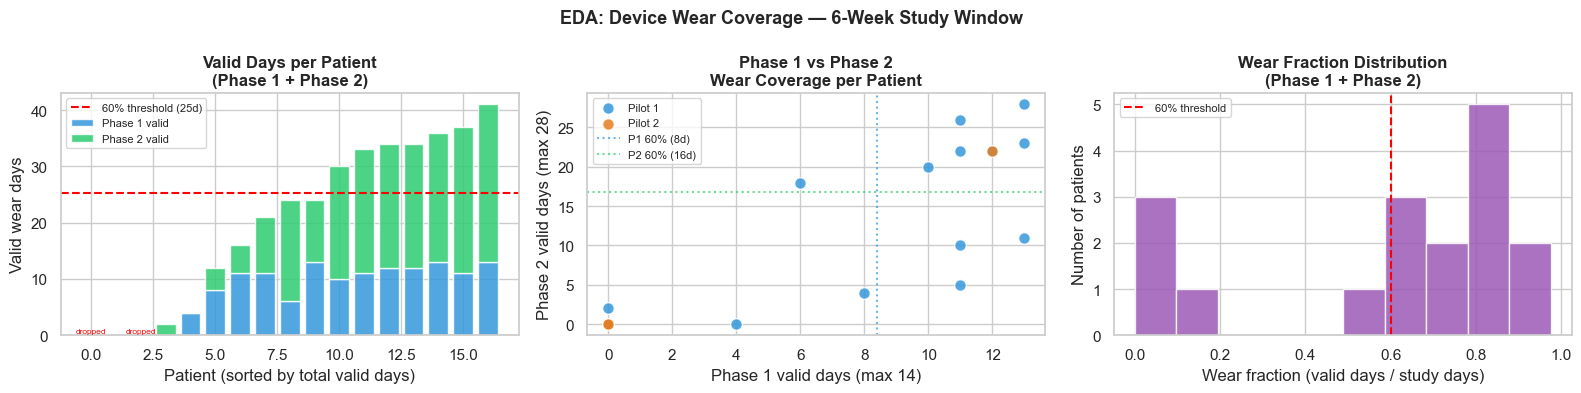

In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Phase 1: days 0–13 (14 days max), Phase 2: days 14–41 (28 days max)
PHASE1_MAX_DAYS = PHASE1_DAYS[1] - PHASE1_DAYS[0] + 1   # 14
PHASE2_MAX_DAYS = PHASE2_DAYS[1] - PHASE2_DAYS[0] + 1   # 28
STUDY_MAX_DAYS  = PHASE1_MAX_DAYS + PHASE2_MAX_DAYS       # 42 (6 weeks)

def phase_coverage(df, phase_label):
    sub = df[df['phase'] == phase_label]
    return sub.groupby('user_id').agg(
        rows       = ('date', 'nunique'),
        valid_days = ('valid_wear_day', 'sum'),
    ).rename(columns={'rows': f'{phase_label}_days', 'valid_days': f'{phase_label}_valid'})

p1_cov = phase_coverage(panel, 'phase1')
p2_cov = phase_coverage(panel, 'phase2')

study_panel = panel[panel['phase'].isin(['phase1', 'phase2'])]
overall = study_panel.groupby(['user_id', 'pilot']).agg(
    study_days  = ('date', 'nunique'),
    valid_days  = ('valid_wear_day', 'sum'),
).reset_index()

coverage = overall.join(p1_cov, on='user_id').join(p2_cov, on='user_id').fillna(0)
coverage['pilot']         = overall['pilot'].values   # restore int dtype after join
coverage['wear_fraction'] = coverage['valid_days'] / coverage['study_days'].replace(0, np.nan)

coverage['in_phase1'] = coverage['phase1_days'] > 0
coverage['in_phase2'] = coverage['phase2_days'] > 0
coverage['dropped']   = coverage['in_phase1'] & ~coverage['in_phase2']

print('=== Per-user wear coverage (Phase 1 + Phase 2 only) ===')
print(f'  Study window         : {STUDY_MAX_DAYS} days max (Phase1: {PHASE1_MAX_DAYS}d + Phase2: {PHASE2_MAX_DAYS}d)')
print(f'  Median valid days    : {coverage["valid_days"].median():.0f} / {STUDY_MAX_DAYS}')
print(f'  Min / Max valid days : {coverage["valid_days"].min():.0f} / {coverage["valid_days"].max():.0f}')
print(f'  Users in Phase 1     : {coverage["in_phase1"].sum()}')
print(f'  Users in Phase 2     : {coverage["in_phase2"].sum()}')
print(f'  Users in BOTH phases : {(coverage["in_phase1"] & coverage["in_phase2"]).sum()}')
print(f'  Users who dropped (Phase 1 only): {coverage["dropped"].sum()}')

if coverage['dropped'].any():
    print('\n  Dropped users:')
    print(coverage[coverage['dropped']][['user_id', 'pilot', 'phase1_days', 'phase2_days', 'valid_days']].to_string(index=False))

PILOT_COLORS = {1: '#3498db', 2: '#e67e22'}
cov_sorted   = coverage.sort_values('valid_days').reset_index(drop=True)
fig, axes    = plt.subplots(1, 3, figsize=(16, 4))

x = np.arange(len(cov_sorted))
axes[0].bar(x, cov_sorted['phase1_valid'], label='Phase 1 valid', color='#3498db', alpha=0.85)
axes[0].bar(x, cov_sorted['phase2_valid'], bottom=cov_sorted['phase1_valid'],
            label='Phase 2 valid', color='#2ecc71', alpha=0.85)
axes[0].axhline(STUDY_MAX_DAYS * 0.6, color='red', linestyle='--',
                label=f'60% threshold ({int(STUDY_MAX_DAYS * 0.6)}d)')
for i, row in cov_sorted.iterrows():
    if row['dropped']:
        axes[0].annotate('dropped', (i, row['valid_days'] + 0.3),
                         fontsize=6, color='red', ha='center')
axes[0].set_xlabel('Patient (sorted by total valid days)')
axes[0].set_ylabel('Valid wear days')
axes[0].set_title('Valid Days per Patient\n(Phase 1 + Phase 2)', fontweight='bold')
axes[0].legend(fontsize=8)

for pid, pc in PILOT_COLORS.items():
    mask = cov_sorted['pilot'] == pid
    if mask.any():
        axes[1].scatter(
            cov_sorted.loc[mask, 'phase1_valid'],
            cov_sorted.loc[mask, 'phase2_valid'],
            color=pc, s=70, alpha=0.85, edgecolors='white', label=f'Pilot {pid}'
        )
axes[1].axvline(PHASE1_MAX_DAYS * 0.6, color='#3498db', linestyle=':',
                alpha=0.7, label=f'P1 60% ({int(PHASE1_MAX_DAYS*0.6)}d)')
axes[1].axhline(PHASE2_MAX_DAYS * 0.6, color='#2ecc71', linestyle=':',
                alpha=0.7, label=f'P2 60% ({int(PHASE2_MAX_DAYS*0.6)}d)')
axes[1].set_xlabel(f'Phase 1 valid days (max {PHASE1_MAX_DAYS})')
axes[1].set_ylabel(f'Phase 2 valid days (max {PHASE2_MAX_DAYS})')
axes[1].set_title('Phase 1 vs Phase 2\nWear Coverage per Patient', fontweight='bold')
axes[1].legend(fontsize=8)

axes[2].hist(cov_sorted['wear_fraction'].dropna(), bins=10,
             color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].axvline(0.60, color='red', linestyle='--', label='60% threshold')
axes[2].set_xlabel('Wear fraction (valid days / study days)')
axes[2].set_ylabel('Number of patients')
axes[2].set_title('Wear Fraction Distribution\n(Phase 1 + Phase 2)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('EDA: Device Wear Coverage — 6-Week Study Window', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_wear_coverage.png', dpi=120, bbox_inches='tight')
plt.show()


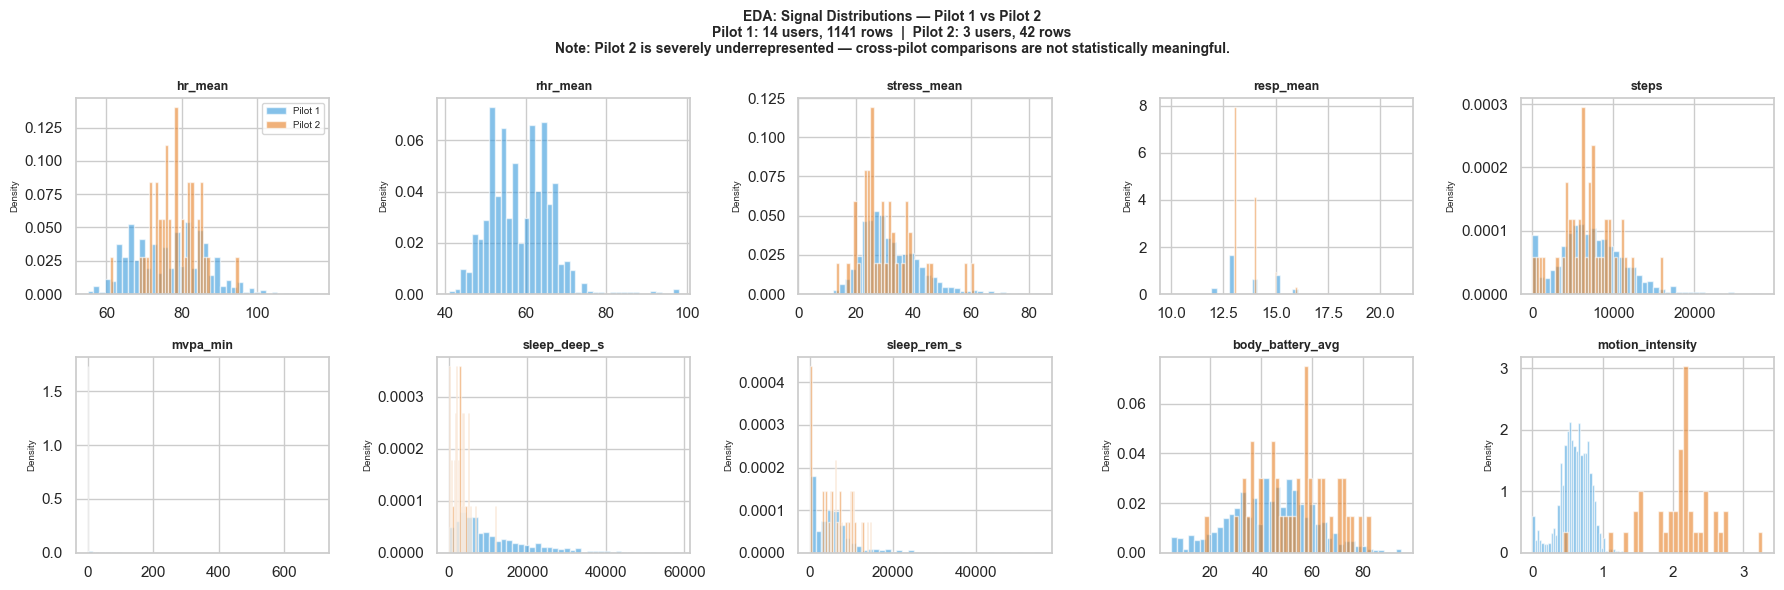

=== Pilot comparison: median signal values ===
(Pilot 1: 14 users, 1141 rows | Pilot 2: 3 users, 42 rows)
  hr_mean                   Pilot 1:     77.0   Pilot 2:     78.0
  rhr_mean                  Pilot 1:     58.0   Pilot 2:      nan
  stress_mean               Pilot 1:     29.0   Pilot 2:     27.5
  resp_mean                 Pilot 1:     13.0   Pilot 2:     13.0
  steps                     Pilot 1:   7034.0   Pilot 2:   6512.0
  mvpa_min                  Pilot 1:     50.0   Pilot 2:      0.0

Caution: Pilot 2 medians based on ≤3 users. Do not interpret as population differences.


In [11]:
# spo2_mean (6.6% coverage) and rmssd_ms (0% coverage) removed — excluded from ML pipeline.
plot_cols = [c for c in ['hr_mean', 'rhr_mean', 'stress_mean', 'resp_mean',
                          'steps', 'mvpa_min', 'sleep_deep_s', 'sleep_rem_s',
                          'body_battery_avg', 'motion_intensity'] if c in panel.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(plot_cols[:10]):
    data_p1 = panel[panel['pilot'] == 1][col].dropna()
    data_p2 = panel[panel['pilot'] == 2][col].dropna()
    axes[i].hist(data_p1, bins=40, alpha=0.6, color='#3498db', label='Pilot 1', density=True)
    axes[i].hist(data_p2, bins=40, alpha=0.6, color='#e67e22', label='Pilot 2', density=True)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=7)
    if i == 0:
        axes[i].legend(fontsize=7)

n_p1_users = panel[panel['pilot'] == 1]['user_id'].nunique()
n_p2_users = panel[panel['pilot'] == 2]['user_id'].nunique()
r_p1       = len(panel[panel['pilot'] == 1])
r_p2       = len(panel[panel['pilot'] == 2])

plt.suptitle(
    f'EDA: Signal Distributions — Pilot 1 vs Pilot 2\n'
    f'Pilot 1: {n_p1_users} users, {r_p1} rows  |  Pilot 2: {n_p2_users} users, {r_p2} rows\n'
    f'Note: Pilot 2 is severely underrepresented — cross-pilot comparisons are not statistically meaningful.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('=== Pilot comparison: median signal values ===')
print(f'(Pilot 1: {n_p1_users} users, {r_p1} rows | Pilot 2: {n_p2_users} users, {r_p2} rows)')
compare_cols = [c for c in ['hr_mean', 'rhr_mean', 'stress_mean', 'resp_mean', 'steps', 'mvpa_min'] if c in panel.columns]
for col in compare_cols:
    m1 = panel[panel['pilot'] == 1][col].median()
    m2 = panel[panel['pilot'] == 2][col].median()
    print(f'  {col:<25} Pilot 1: {m1:>8.1f}   Pilot 2: {m2:>8.1f}')
print('\nCaution: Pilot 2 medians based on ≤3 users. Do not interpret as population differences.')


=== Class balance preview (weekly aggregates) ===
Target              Active   Inactive   Active %        n
------------------------------------------------------------
mvpa_420                80         83      49.1%      163
mvpa_150               134         29      82.2%      163

KEY FINDING:
  mvpa_420 (WHO paediatric: 60 min/day) is the primary target.
  mvpa_150 (WHO adult comparison) is secondary.
  Class balance for mvpa_420 shown above — verify ≥25% inactive weeks.


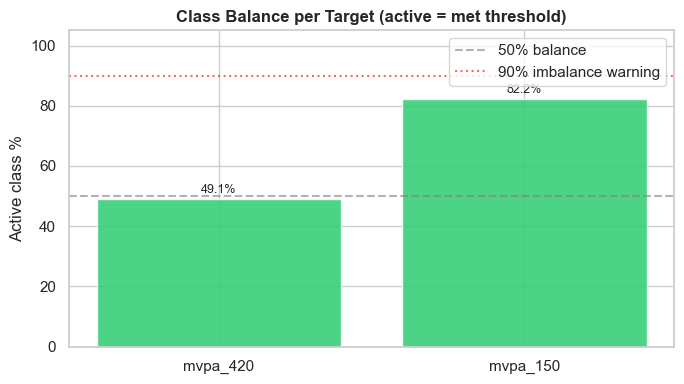

In [12]:
tmp = panel.copy()
tmp['year_week'] = tmp['date'].dt.isocalendar().year.astype(str) + '_' + \
                   tmp['date'].dt.isocalendar().week.astype(str).str.zfill(2)

weekly_preview = tmp.groupby(['user_id', 'year_week']).agg(
    mvpa_sum   = ('mvpa_min', 'sum'),
    steps_mean = ('steps',    'mean'),
    valid_days = ('valid_wear_day', 'sum'),
).reset_index()

weekly_preview = weekly_preview[weekly_preview['valid_days'] >= MIN_VALID_DAYS]

print('=== Class balance preview (weekly aggregates) ===')
print(f'{"Target":<15} {"Active":>10} {"Inactive":>10} {"Active %":>10} {"n":>8}')
print('-' * 60)

balance_data = []
for tgt_name, cfg in TARGETS.items():
    col = cfg['col']
    thr = cfg['threshold']
    if col not in weekly_preview.columns:
        continue
    labels = (weekly_preview[col] >= thr).astype(int)
    n_active   = labels.sum()
    n_inactive = len(labels) - n_active
    pct_active = n_active / len(labels) * 100
    print(f'{tgt_name:<15} {n_active:>10} {n_inactive:>10} {pct_active:>9.1f}% {len(labels):>8}')
    balance_data.append({'target': tgt_name, 'active_pct': pct_active})

print()
print('KEY FINDING:')
print('  mvpa_420 (WHO paediatric: 60 min/day) is the primary target.')
print('  mvpa_150 (WHO adult comparison) is secondary.')
print('  Class balance for mvpa_420 shown above — verify ≥25% inactive weeks.')

fig, ax = plt.subplots(figsize=(7, 4))
bd = pd.DataFrame(balance_data)
bars = ax.bar(bd['target'], bd['active_pct'], color=['#e74c3c' if p > 90 else '#2ecc71' for p in bd['active_pct']], alpha=0.85, edgecolor='white')
ax.axhline(50, color='grey', linestyle='--', alpha=0.6, label='50% balance')
ax.axhline(90, color='red',  linestyle=':', alpha=0.6, label='90% imbalance warning')
ax.set_ylim(0, 105)
ax.set_ylabel('Active class %')
ax.set_title('Class Balance per Target (active = met threshold)', fontweight='bold')
ax.legend()
for bar, val in zip(bars, bd['active_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 1.5 Correlation Analysis

Computes a pairwise correlation heatmap of physiological signals and point-biserial correlations between daily signals and next-week activity targets.

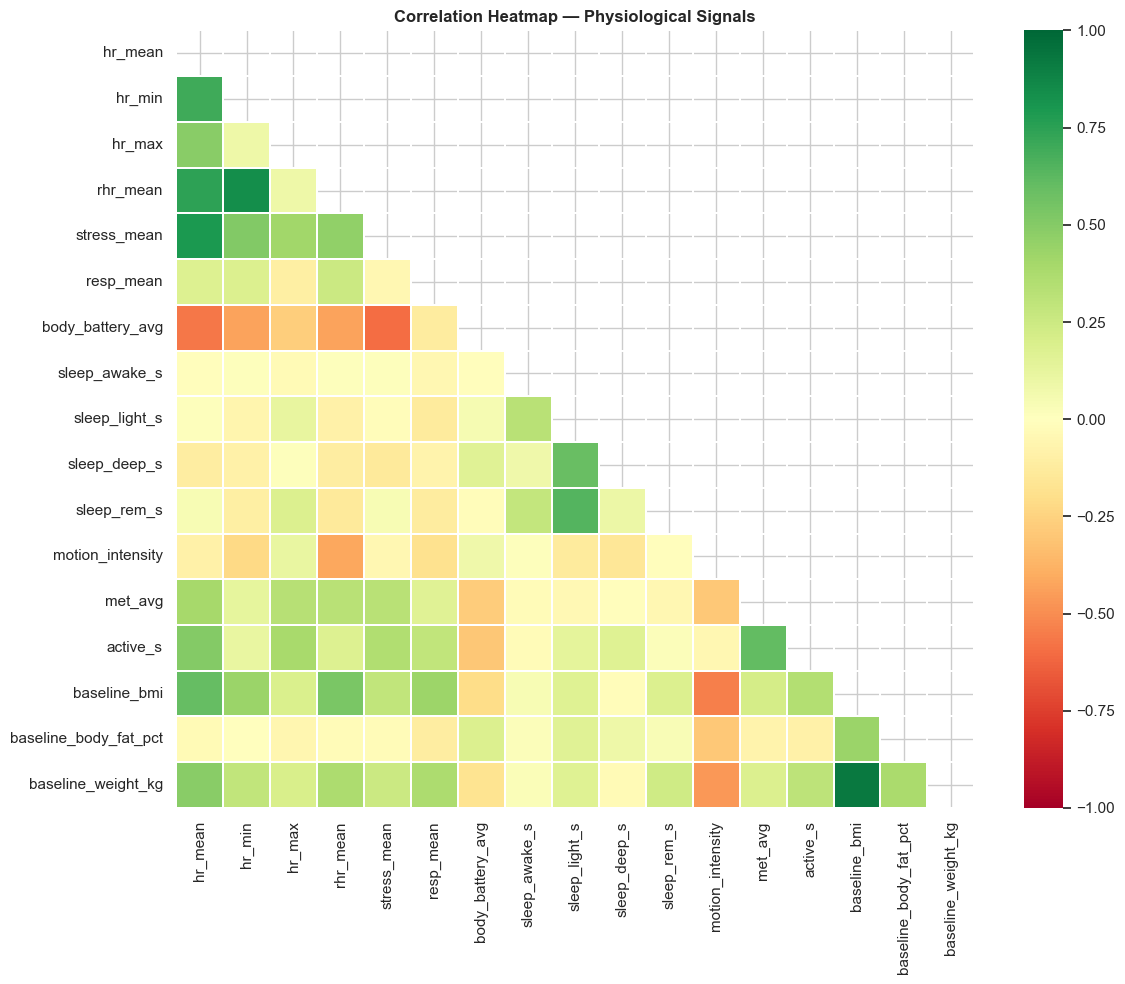

Pairs with |r| > 0.80:
   Feature A          Feature B     r
baseline_bmi baseline_weight_kg 0.927
      hr_min           rhr_mean 0.840


In [13]:
heatmap_cols = [c for c in PHYSIOL_COLS if c in panel.columns]
corr_matrix = panel[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.3, ax=ax
)
ax.set_title('Correlation Heatmap — Physiological Signals', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'corr_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            high_corr.append({'Feature A': corr_matrix.columns[i], 'Feature B': corr_matrix.columns[j], 'r': round(r, 3)})

if high_corr:
    print('Pairs with |r| > 0.80:')
    print(pd.DataFrame(high_corr).sort_values('r', ascending=False).to_string(index=False))

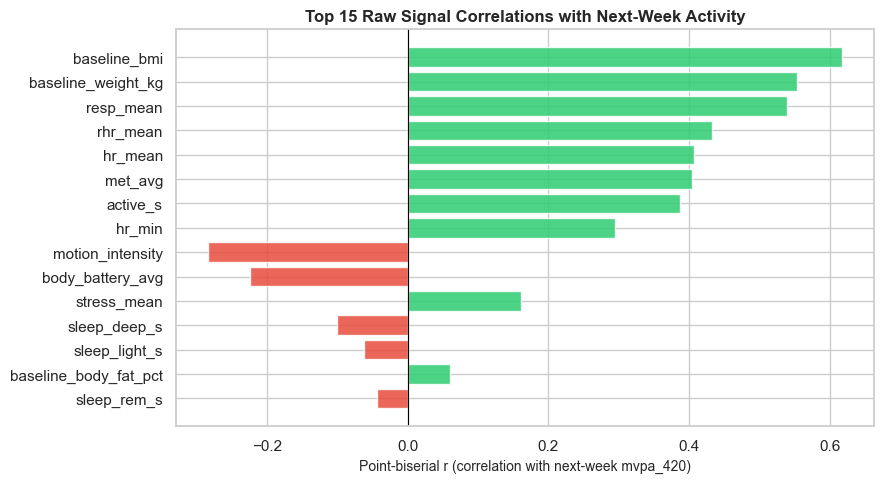

Top 10 features by |r| with next-week mvpa_420 (WHO paediatric):
           Feature      r   p
      baseline_bmi  0.618 0.0
baseline_weight_kg  0.554 0.0
         resp_mean  0.539 0.0
          rhr_mean  0.433 0.0
           hr_mean  0.407 0.0
           met_avg  0.405 0.0
          active_s  0.388 0.0
            hr_min  0.295 0.0
  motion_intensity -0.284 0.0
  body_battery_avg -0.224 0.0


In [14]:
tmp2 = panel.copy()
tmp2['year_week'] = tmp2['date'].dt.isocalendar().year.astype(str) + '_' + \
                    tmp2['date'].dt.isocalendar().week.astype(str).str.zfill(2)
week_tgt = tmp2.groupby(['user_id', 'year_week']).agg(
    mvpa_sum   = ('mvpa_min', 'sum'),
    steps_mean = ('steps',    'mean'),
).reset_index()
week_tgt['mvpa_420_label'] = (week_tgt['mvpa_sum'] >= 420).astype(int)
week_tgt['mvpa_420_next']  = week_tgt.groupby('user_id')['mvpa_420_label'].shift(-1)

daily_weekly = tmp2.merge(week_tgt[['user_id', 'year_week', 'mvpa_420_next']], on=['user_id', 'year_week'], how='left')

corr_results = []
for col in [c for c in PHYSIOL_COLS if c in daily_weekly.columns]:
    sub = daily_weekly[['mvpa_420_next', col]].dropna()
    if len(sub) < 20:
        continue
    r, p = pointbiserialr(sub['mvpa_420_next'], sub[col])
    corr_results.append({'Feature': col, 'r': round(r, 3), 'p': round(p, 4), 'abs_r': abs(r)})

corr_df = pd.DataFrame(corr_results).sort_values('abs_r', ascending=False)

top = corr_df.head(15)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in top['r']]
ax.barh(top['Feature'][::-1], top['r'][::-1], color=colors[::-1], alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial r (correlation with next-week mvpa_420)', fontsize=10)
ax.set_title('Top 15 Raw Signal Correlations with Next-Week Activity', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_target_corr.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features by |r| with next-week mvpa_420 (WHO paediatric):')
print(corr_df.head(10)[['Feature', 'r', 'p']].to_string(index=False))

## 1.6 Feature Engineering

Computes five cumulative feature types per signal per user–week, using only data available up to the end of that week:

| Prefix | Description |
|---|---|
| `recent_` | Mean over the preceding 7 days |
| `cumul_mean_` | Mean over all available history |
| `cumul_std_` | Standard deviation over all available history |
| `trend_` | Linear slope over all available history (via `numpy.polyfit`) |
| `delta_` | Difference between `recent_` and `cumul_mean_` |

In [15]:

def compute_cumulative_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build 5-prefix cumulative features per signal per user-week."""
    df = df.copy()
    df['year_week'] = (df['date'].dt.isocalendar().year.astype(str) + '_' +
                       df['date'].dt.isocalendar().week.astype(str).str.zfill(2))

    feat_cols = [c for c in PHYSIOL_COLS if c in df.columns]  # physiology only — activity excluded to avoid autocorrelation
    records = []

    for user_id, udf in df.groupby('user_id'):
        udf = udf.sort_values('date')
        weeks = udf['year_week'].unique()

        for wk in weeks:
            wk_end_date = udf[udf['year_week'] == wk]['date'].max()
            history     = udf[udf['date'] <= wk_end_date]
            recent_7d   = udf[(udf['date'] <= wk_end_date) &
                               (udf['date'] >= wk_end_date - pd.Timedelta(days=6))]

            row = {'user_id': user_id, 'year_week': wk, 'pilot': udf['pilot'].iloc[0]}

            for col in feat_cols:
                h = history[col].dropna().values
                r = recent_7d[col].dropna().values

                row[f'recent_{col}']    = r.mean()    if len(r) >= 1 else np.nan
                row[f'cumul_mean_{col}'] = h.mean()   if len(h) >= 1 else np.nan
                row[f'cumul_std_{col}'] = h.std()     if len(h) >= 3 else np.nan
                row[f'trend_{col}']     = (np.polyfit(np.arange(len(h)), h, 1)[0]
                                           if len(h) >= 5 else np.nan)
                row[f'delta_{col}']     = (row[f'recent_{col}'] - row[f'cumul_mean_{col}']
                                           if pd.notna(row[f'recent_{col}']) and pd.notna(row[f'cumul_mean_{col}'])
                                           else np.nan)
            records.append(row)

    return pd.DataFrame(records)

print('Computing cumulative features — this may take a few minutes...')
cumul_df = compute_cumulative_features(panel)

feature_cols = [c for c in cumul_df.columns if c not in ['user_id', 'year_week', 'pilot']]
print(f'\nCumulative feature matrix: {len(cumul_df):,} user-weeks × {len(feature_cols)} features')
print(f'Users: {cumul_df["user_id"].nunique()}')

Computing cumulative features — this may take a few minutes...

Cumulative feature matrix: 205 user-weeks × 85 features
Users: 17


In [16]:
prefix_counts = {}
for p in ['recent_', 'cumul_mean_', 'cumul_std_', 'trend_', 'delta_']:
    prefix_counts[p] = sum(1 for c in feature_cols if c.startswith(p))

print('=== Feature engineering summary ===')
print(f'  Input signals  : {len([c for c in ALL_SIGNAL_COLS if c in panel.columns])}')
print(f'  Prefix types   : 5  (recent, cumul_mean, cumul_std, trend, delta)')
print()
for prefix, count in prefix_counts.items():
    print(f'  {prefix:<20} {count:>4} features')
print(f'  {"TOTAL":<20} {len(feature_cols):>4} features')

feat_missing = (cumul_df[feature_cols].isnull().mean() * 100).sort_values(ascending=False)
print(f'\nFeatures with >30% missing (will be dropped): {(feat_missing > 30).sum()}')
print(f'Features retained after 30% filter         : {(feat_missing <= 30).sum()}')

=== Feature engineering summary ===
  Input signals  : 22
  Prefix types   : 5  (recent, cumul_mean, cumul_std, trend, delta)

  recent_                17 features
  cumul_mean_            17 features
  cumul_std_             17 features
  trend_                 17 features
  delta_                 17 features
  TOTAL                  85 features

Features with >30% missing (will be dropped): 0
Features retained after 30% filter         : 85


## 1.7 Activity Target Definition

Defines two binary targets based on WHO physical activity guidelines:

| Target | Threshold | Reference |
|---|---|---|
| `mvpa_420` (primary) | Weekly MVPA ≥ 420 min | WHO (2020) paediatric: 60 min/day |
| `mvpa_150` (comparison) | Weekly MVPA ≥ 150 min | WHO (2019) adult guideline |

Features at week *t* predict the target at week *t*+1.

In [17]:

def build_weekly_targets(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate to user-week level and create next-week binary labels."""
    df = df.copy()
    df['year_week'] = (df['date'].dt.isocalendar().year.astype(str) + '_' +
                       df['date'].dt.isocalendar().week.astype(str).str.zfill(2))

    frames = []
    for user_id, udf in df.groupby('user_id'):
        weekly = udf.groupby('year_week').agg(
            mvpa_sum   = ('mvpa_min',       'sum'),
            steps_mean = ('steps',          'mean'),
            valid_days = ('valid_wear_day', 'sum'),
        ).reset_index()

        weekly = weekly[weekly['valid_days'] >= MIN_VALID_DAYS].copy()
        if len(weekly) < 2:
            continue

        for tgt_name, cfg in TARGETS.items():
            col = cfg['col']
            thr = cfg['threshold']
            weekly[f'label_{tgt_name}']    = (weekly[col] >= thr).astype(int)
            weekly[f'next_{tgt_name}']     = weekly[f'label_{tgt_name}'].shift(-1)

        weekly['user_id'] = user_id
        weekly = weekly.iloc[:-1]  # drop last week (no next-week label)
        frames.append(weekly)

    return pd.concat(frames, ignore_index=True)

target_df = build_weekly_targets(panel)

next_cols  = ['user_id', 'year_week'] + [c for c in target_df.columns if c.startswith('next_')]
model_df   = cumul_df.merge(target_df[next_cols], on=['user_id', 'year_week'], how='inner')

print(f'Model dataset: {len(model_df):,} user-weeks | {model_df["user_id"].nunique()} users')
print()
print(f'{"Target":<15} {"Active":>8} {"Inactive":>10} {"Active %":>10} {"n":>6}')
print('-' * 55)
for tgt_name, cfg in TARGETS.items():
    col = f'next_{tgt_name}'
    if col not in model_df.columns:
        continue
    s = model_df[col].dropna()
    n_active = int(s.sum())
    n_inact  = int(len(s) - n_active)
    pct_a    = n_active / len(s) * 100
    print(f'{tgt_name:<15} {n_active:>8} {n_inact:>10} {pct_a:>9.1f}% {len(s):>6}')

print(f'\nPrimary target selected: {PRIMARY_TARGET}')
print(f'Reason: most balanced class distribution — avoids trivial majority-class prediction')

Model dataset: 150 user-weeks | 12 users

Target            Active   Inactive   Active %      n
-------------------------------------------------------
mvpa_420              74         76      49.3%    150
mvpa_150             122         28      81.3%    150

Primary target selected: mvpa_420
Reason: most balanced class distribution — avoids trivial majority-class prediction


In [18]:
import warnings
from scipy.stats import mannwhitneyu

TARGET_COL = f'next_{PRIMARY_TARGET}'
eff_df  = model_df.dropna(subset=[TARGET_COL]).copy()
active   = eff_df[eff_df[TARGET_COL] == 1]
inactive = eff_df[eff_df[TARGET_COL] == 0]

def cohens_d(a, b):
    """Pooled-SD Cohen's d (Glass's formula with pooled variance)."""
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled_sd = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else 0.0

raw_signal_cols = [f'cumul_mean_{c}' for c in PHYSIOL_COLS if f'cumul_mean_{c}' in eff_df.columns]

effect_rows = []
for col in raw_signal_cols:
    a_vals = active[col].dropna()
    b_vals = inactive[col].dropna()
    if len(a_vals) < 5 or len(b_vals) < 5:
        continue
    d = cohens_d(a_vals, b_vals)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _, p_mwu = mannwhitneyu(a_vals, b_vals, alternative='two-sided')
    effect_rows.append({'feature': col.replace('cumul_mean_', ''),  # strip prefix for display
                        'cohens_d': d, 'abs_d': abs(d),
                        'p_mwu': p_mwu,
                        'mean_active': a_vals.mean(), 'mean_inactive': b_vals.mean()})

eff_tbl = pd.DataFrame(effect_rows).sort_values('abs_d', ascending=False)

print(f'=== Cohen\'s d Effect Sizes: Active vs Inactive weeks ({TARGET_COL}) ===')
print(f'  Active weeks   : {len(active):>4}  (next-week MVPA ≥420 min)')
print(f'  Inactive weeks : {len(inactive):>4}  (next-week MVPA <420 min)')
print(f'  Features       : cumul_mean_ prefix — patient\'s running physiological baseline')
print()
print(f"  {'Feature':<25} {'Active μ':>9} {'Inactive μ':>11} {'Cohen' + chr(39) + 's d':>10}  Magnitude")
print(f'  {"-"*70}')
for _, row in eff_tbl.iterrows():
    d = row['cohens_d']
    mag = 'LARGE' if abs(d) >= 0.8 else ('MEDIUM' if abs(d) >= 0.5 else ('small' if abs(d) >= 0.2 else 'negligible'))
    print(f'  {row.feature:<25} {row.mean_active:>9.2f} {row.mean_inactive:>11.2f} {d:>10.3f}  {mag}')

print()
large = eff_tbl[eff_tbl.abs_d >= 0.8]
medium = eff_tbl[(eff_tbl.abs_d >= 0.5) & (eff_tbl.abs_d < 0.8)]
print(f'  LARGE effects (d≥0.80): {len(large)}  →  {", ".join(large.feature.tolist()) if len(large) else "none"}')
print(f'  MEDIUM effects (d≥0.50): {len(medium)}  →  {", ".join(medium.feature.tolist()) if len(medium) else "none"}')
print()
if len(large) == 0 and len(medium) <= 2:
    print('  ⚠  Most physiological signals show only SMALL/negligible effect sizes.')
    print('     This is a structural data challenge — not a modelling failure:')
    print('     the week-to-week difference in physiology between active and inactive weeks')
    print('     is too subtle to generalise reliably from 9 training patients.')
    print('     This quantifies WHY the model achieves AUC=0.571 rather than ≥0.70.')
else:
    print('  Features with LARGE/MEDIUM effects are the most thesis-defensible features.')
    print('  A well-powered study (≥30 patients) could reliably exploit these signals.')

=== Cohen's d Effect Sizes: Active vs Inactive weeks (next_mvpa_420) ===
  Active weeks   :   74  (next-week MVPA ≥420 min)
  Inactive weeks :   76  (next-week MVPA <420 min)
  Features       : cumul_mean_ prefix — patient's running physiological baseline

  Feature                    Active μ  Inactive μ  Cohen's d  Magnitude
  ----------------------------------------------------------------------
  rhr_mean                      63.02       54.78      1.996  LARGE
  resp_mean                     14.40       13.18      1.928  LARGE
  baseline_bmi                  34.19       26.79      1.892  LARGE
  hr_mean                       81.39       72.39      1.625  LARGE
  baseline_weight_kg            94.73       70.66      1.548  LARGE
  hr_min                        57.70       52.23      1.502  LARGE
  met_avg                        1.60        1.30      1.341  LARGE
  sleep_deep_s                6219.97    13413.45     -1.321  LARGE
  stress_mean                   33.78       28.47     

In [19]:
def icc_one_way(data, group_col, value_col):
    """One-way random effects ICC(1,1) — no external package needed."""
    groups = data.dropna(subset=[value_col]).groupby(group_col)[value_col].apply(list)
    groups = [np.array(g) for g in groups if len(g) > 1]
    if len(groups) < 2:
        return np.nan
    k = len(groups)
    n_sizes = [len(g) for g in groups]
    N = sum(n_sizes)
    grand_mean = np.concatenate(groups).mean()

    SSB = sum(n * (g.mean() - grand_mean)**2 for n, g in zip(n_sizes, groups))
    SSW = sum(((g - g.mean())**2).sum() for g in groups)

    MSB = SSB / (k - 1)
    MSW = SSW / (N - k) if N > k else np.nan
    if MSW is None or MSB + MSW == 0:
        return np.nan

    # Adjusted k* for unbalanced groups
    k_star = (N - sum(n**2 for n in n_sizes) / N) / (k - 1)
    icc = (MSB - MSW) / (MSB + (k_star - 1) * MSW)
    return float(np.clip(icc, 0, 1))

icc_results = []
icc_cols = [c for c in PHYSIOL_COLS if c in panel.columns]
for col in icc_cols:
    icc_val = icc_one_way(panel, 'user_id', col)
    icc_results.append({'feature': col, 'icc': icc_val})

icc_tbl = pd.DataFrame(icc_results).sort_values('icc', ascending=False)

print('=== ICC: What fraction of signal variance is between patients vs within patient? ===')
print()
print(f'  {"Feature":<25} {"ICC":>8}  Interpretation')
print(f'  {"-"*65}')
for _, row in icc_tbl.iterrows():
    icc = row['icc']
    if np.isnan(icc):
        interp = '—'
    elif icc >= 0.75:
        interp = 'HIGH — patient identity dominates; weekly model unreliable'
    elif icc >= 0.50:
        interp = 'MODERATE — both patient and weekly variation present'
    else:
        interp = 'LOW — week-to-week variation dominates' 
    icc_str = f'{icc:.3f}' if not np.isnan(icc) else ' nan'
    print(f'  {row.feature:<25} {icc_str:>8}  {interp}')

high_icc = icc_tbl[icc_tbl.icc >= 0.75]
print()
print(f'  Signals with HIGH ICC (≥0.75): {len(high_icc)}/{len(icc_tbl)}')
print(f'  → {", ".join(high_icc.feature.tolist()) if len(high_icc) else "none"}')
print()
print('  THESIS IMPLICATION:')
if len(high_icc) >= len(icc_tbl) // 2:
    print('  Most physiological signals have HIGH ICC — the dominant source of variance')
    print('  is between patients, not between weeks. A LogisticRegression trained on 9')
    print('  patients will memorise patient-level profiles rather than learn generalizable')
    print('  weekly patterns. This structural constraint explains F1_active=0.000 and')
    print('  the bimodal probabilities (0.000 vs 1.000) observed in the prediction audit.')
    print('  Resolving this requires either: (a) ≥30 patients for better coverage of the')
    print('  physiological space, or (b) within-patient modelling (change-from-baseline')
    print('  features) rather than raw signal levels.')
else:
    print('  ICC values are moderate — patient and weekly variation both contribute.')
    print('  With more patients, the model should be able to exploit weekly patterns.')


=== ICC: What fraction of signal variance is between patients vs within patient? ===

  Feature                        ICC  Interpretation
  -----------------------------------------------------------------
  baseline_weight_kg           1.000  HIGH — patient identity dominates; weekly model unreliable
  baseline_body_fat_pct        1.000  HIGH — patient identity dominates; weekly model unreliable
  baseline_bmi                 1.000  HIGH — patient identity dominates; weekly model unreliable
  motion_intensity             0.771  HIGH — patient identity dominates; weekly model unreliable
  rhr_mean                     0.696  MODERATE — both patient and weekly variation present
  hr_mean                      0.641  MODERATE — both patient and weekly variation present
  resp_mean                    0.583  MODERATE — both patient and weekly variation present
  hr_min                       0.496  LOW — week-to-week variation dominates
  met_avg                      0.494  LOW — week-to-wee

---
## Act 2 — Modelling

## 2.1 Train / Validation Split

Reserves 20% of patients as a held-out test set. The remaining 80% are used for 3-fold Stratified Group K-Fold cross-validation, grouped by `user_id`.

In [20]:
np.random.seed(RANDOM_SEED)

all_users = model_df['user_id'].unique()
n_holdout = max(1, int(len(all_users) * HOLD_OUT_FRAC))

user_pilot = model_df.drop_duplicates('user_id').set_index('user_id')['pilot']
holdout_users = []
for pilot_id in sorted(user_pilot.unique()):
    pilot_users = user_pilot[user_pilot == pilot_id].index.tolist()
    n = max(1, round(len(pilot_users) * HOLD_OUT_FRAC))
    holdout_users += list(np.random.choice(pilot_users, size=min(n, len(pilot_users)), replace=False))

train_users = [u for u in all_users if u not in holdout_users]
train_df    = model_df[model_df['user_id'].isin(train_users)].copy()
holdout_df  = model_df[model_df['user_id'].isin(holdout_users)].copy()

print('=== Train / Hold-out Split ===')
print(f'  Total patients   : {len(all_users)}')
print(f'  Train patients   : {len(train_users):>4}  ({len(train_users)/len(all_users):.0%})')
print(f'  Hold-out patients: {len(holdout_users):>4}  ({len(holdout_users)/len(all_users):.0%})')
print(f'  Train user-weeks : {len(train_df):,}')
print(f'  Hold-out user-wks: {len(holdout_df):,}')
print(f'  Random seed      : {RANDOM_SEED}')
print()
print('IMPORTANT: Hold-out data is sealed. It will not be accessed until Section 3.1.')


=== Train / Hold-out Split ===
  Total patients   : 12
  Train patients   :    9  (75%)
  Hold-out patients:    3  (25%)
  Train user-weeks : 135
  Hold-out user-wks: 15
  Random seed      : 42

IMPORTANT: Hold-out data is sealed. It will not be accessed until Section 3.1.


In [21]:
n_raw      = raw['User Id'].nunique()
n_raw_rows = len(raw)

n_panel      = panel['user_id'].nunique()
n_panel_rows = len(panel)

n_cumul     = cumul_df['user_id'].nunique()
n_cumul_wks = len(cumul_df)

n_model     = model_df['user_id'].nunique()
n_model_wks = len(model_df)

n_holdout = len(holdout_users)
n_train   = n_model - n_holdout
n_ho_wks  = model_df[model_df['user_id'].isin(holdout_users)].shape[0]
n_tr_wks  = n_model_wks - n_ho_wks

raw_users   = set(raw['User Id'].unique())
panel_users = set(panel['user_id'].unique())
model_users = set(model_df['user_id'].unique())
step1_excl  = sorted(raw_users - panel_users)
step2_excl  = sorted(panel_users - model_users)

SEP = '─' * 72
print('=' * 72)
print('  INCLUSION / EXCLUSION FUNNEL — eBATTLE Pilot 1 & 2')
print('=' * 72)

print(f'\n  START   Raw Garmin export  (Pilot 1 + Pilot 2 combined)')
print(f'          {n_raw} users   {n_raw_rows:,} rows  (1 row = 1 user × 1 calendar day)')

print(f'\n  ▼  EXCLUSION A  — {n_raw - n_panel} users excluded')
print(f'     Filters applied in build_panel():')
print(f'       1. Remove rows with zero device wear  (wear_pct == 0)')
print(f'       2. Remove rows with >50% null core biosignals')
print(f'       3. Restrict to study window: Phase 1 + Phase 2 (days 0–41 from day1)')
print(f'       → Users with no valid-wear rows remaining are dropped entirely')
print(f'     Excluded user IDs:')
for uid in step1_excl:
    print(f'       – {uid[:16]}…')

print(f'\n  STEP 1  Clean panel  (valid wear days within study window)')
print(f'          {n_panel} users   {n_panel_rows:,} rows')
print(f'          Valid wear day = ≥{MIN_WEAR_PCT:.0f}% daily wear time')

print(f'\n  ▼  EXCLUSION B  — {n_panel - n_model} users excluded')
print(f'     Filters applied in build_weekly_targets():')
print(f'       1. Require ≥{MIN_VALID_DAYS} valid wear days per week  (weeks below threshold dropped)')
print(f'       2. Require ≥2 qualifying weeks per user  (users with fewer dropped entirely)')
print(f"       3. Drop each user's final week  (no next-week activity label available)")
print(f'     Excluded user IDs:')
for uid in step2_excl:
    print(f'       – {uid[:16]}…')

print(f'\n  STEP 2  Model-ready weekly dataset')
print(f'          {n_model} users   {n_model_wks} user-weeks')
print(f'          Features: weekly cumulative physiological aggregates ({len(PHYSIOL_COLS)} input signals)')

print(f'\n  ▼  SPLIT  75% train / 25% hold-out  (group-stratified, random_state=42)')

print(f'\n  STEP 3a  Train set     {n_train} users   {n_tr_wks} user-weeks')
print(f'  STEP 3b  Hold-out set  {n_holdout} users   {n_ho_wks} user-weeks  ★ not seen during training')

print(f'\n  {SEP}')
print(f'  Total attrition  : {n_raw} → {n_model} model-eligible users  ({(n_raw-n_model)/n_raw*100:.0f}% of raw cohort excluded)')
print(f'  Data compression : {n_raw_rows:,} daily rows → {n_model_wks} weekly windows  (via 7-day aggregation)')


  INCLUSION / EXCLUSION FUNNEL — eBATTLE Pilot 1 & 2

  START   Raw Garmin export  (Pilot 1 + Pilot 2 combined)
          35 users   20,440 rows  (1 row = 1 user × 1 calendar day)

  ▼  EXCLUSION A  — 18 users excluded
     Filters applied in build_panel():
       1. Remove rows with zero device wear  (wear_pct == 0)
       2. Remove rows with >50% null core biosignals
       3. Restrict to study window: Phase 1 + Phase 2 (days 0–41 from day1)
       → Users with no valid-wear rows remaining are dropped entirely
     Excluded user IDs:
       – 65a4eecec9173319…
       – 65a4eee6c9173319…
       – 65a4f0c7c9173319…
       – 65b37f4b5b370160…
       – 65f83e4373447e17…
       – 65f991a1ee121d6e…
       – 65fd5d2efbaa535a…
       – 660d34482a069108…
       – 660e9b4f4cb71939…
       – 660ea0e14cb71939…
       – 66193173c4d74e1f…
       – 661d0f456611ff30…
       – 661e7bdc6611ff30…
       – 661f9a166611ff30…
       – 662a458bc594d468…
       – 662a4796c594d468…
       – 6633698c62f8360a…

In [22]:
PHASE1_MAX = 14
PHASE2_MAX = 28
TOTAL_MAX  = PHASE1_MAX + PHASE2_MAX  # 42 days = 6 study weeks

model_user_set   = set(model_df['user_id'].unique())
holdout_user_set = set(holdout_users)

_rows = []
for _uid in sorted(panel['user_id'].unique()):
    _p          = panel[panel['user_id'] == _uid]
    _pilot      = int(_p['pilot'].iloc[0])
    _first_wear = str(_p['day1'].iloc[0])[:10]   # YYYY-MM-DD of first Garmin sync

    _ph1 = _p[_p['phase'] == 'phase1']
    _ph2 = _p[_p['phase'] == 'phase2']
    _ph1_valid = int(_ph1['valid_wear_day'].sum())
    _ph2_valid = int(_ph2['valid_wear_day'].sum())
    _total     = _ph1_valid + _ph2_valid

    if _uid in holdout_user_set:
        _role = 'HOLD-OUT ★'
    elif _uid in model_user_set:
        _role = 'training'
    else:
        _role = 'excluded'

    _rows.append({
        'uid': _uid, 'short': _uid[:8] + '...', 'pilot': _pilot,
        'role': _role, 'first_wear': _first_wear,
        'ph1': _ph1_valid, 'ph2': _ph2_valid, 'total': _total,
    })

print('=' * 112)
print('  PATIENT COMPLIANCE AUDIT — eBATTLE Pilot 1 & 2')
print('  Phase 1 = 14 days  |  Phase 2 = 28 days  |  Full study = 42 days')
print('  HOLD-OUT ★ = sealed test set  |  training = used to train models  |  excluded = insufficient wear data')
print('=' * 112)
print(f'  {"#":<3}  {"Patient ID":<12}  {"Pilot":<6}  {"Role":<13}  '
      f'{"First Wear":<12}  {"Ph1 /14":<9}  {"Ph1 %":<7}  '
      f'{"Ph2 /28":<9}  {"Ph2 %":<7}  {"Total /42":<14}')
print('  ' + '-' * 108)

for _i, _r in enumerate(_rows, 1):
    _ph1_pct = _r['ph1'] / PHASE1_MAX * 100
    _ph2_pct = _r['ph2'] / PHASE2_MAX * 100
    _tot_pct = _r['total'] / TOTAL_MAX * 100
    _ph1_s = f'{_r["ph1"]:>2}/{PHASE1_MAX}'
    _ph2_s = f'{_r["ph2"]:>2}/{PHASE2_MAX}'
    _ph1_pct_s = f'{_ph1_pct:.0f}%'
    _ph2_pct_s = f'{_ph2_pct:.0f}%'
    _tot_s = f'{_r["total"]}/{TOTAL_MAX}  ({_tot_pct:.0f}%)'
    print(f'  {_i:<3}  {_r["short"]:<12}  {_r["pilot"]:<6}  {_r["role"]:<13}  '
          f'{_r["first_wear"]:<12}  {_ph1_s:<9}  {_ph1_pct_s:<7}  '
          f'{_ph2_s:<9}  {_ph2_pct_s:<7}  {_tot_s}')

print()
_ph1_vals = [_r['ph1'] for _r in _rows]
_ph2_vals = [_r['ph2'] for _r in _rows]
print(f'  Median Phase 1 compliance : {np.median(_ph1_vals) / PHASE1_MAX * 100:.0f}%  '
      f'({np.median(_ph1_vals):.0f}/{PHASE1_MAX} valid days)')
print(f'  Median Phase 2 compliance : {np.median(_ph2_vals) / PHASE2_MAX * 100:.0f}%  '
      f'({np.median(_ph2_vals):.0f}/{PHASE2_MAX} valid days)')
print(f'  Patients with 0 valid Phase 1 days : {sum(1 for v in _ph1_vals if v == 0)}  (excluded from model)')
print(f'  Patients with 0 valid Phase 2 days : {sum(1 for v in _ph2_vals if v == 0)}  (excluded from model)')
print()


  PATIENT COMPLIANCE AUDIT — eBATTLE Pilot 1 & 2
  Phase 1 = 14 days  |  Phase 2 = 28 days  |  Full study = 42 days
  HOLD-OUT ★ = sealed test set  |  training = used to train models  |  excluded = insufficient wear data
  #    Patient ID    Pilot   Role           First Wear    Ph1 /14    Ph1 %    Ph2 /28    Ph2 %    Total /42     
  ------------------------------------------------------------------------------------------------------------
  1    660e6538...   2       excluded       2024-06-11     0/14      0%        0/28      0%       0/42  (0%)
  2    660e66b7...   1       excluded       2024-03-11     4/14      29%       0/28      0%       4/42  (10%)
  3    660e9beb...   2       excluded       2024-04-04     0/14      0%        0/28      0%       0/42  (0%)
  4    660ea12b...   1       HOLD-OUT ★     2024-04-04     8/14      57%       4/28      14%      12/42  (29%)
  5    660ea3c7...   1       training       2024-03-04    13/14      93%      28/28      100%     41/42  (98%)
  6  

## 2.2 Feature Selection

Applies two sequential filters fitted on training data only: drops features with more than 30% missing values, then drops one feature from each pair with Pearson |r| > 0.95.

In [23]:
raw_feats = [c for c in feature_cols if c in train_df.columns]

miss_pct      = train_df[raw_feats].isnull().mean()
feats_after_miss = [f for f in raw_feats if miss_pct[f] <= MAX_MISSING_FRAC]
dropped_miss  = len(raw_feats) - len(feats_after_miss)

corr_m = train_df[feats_after_miss].corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > MAX_CORR)]
feature_list  = [f for f in feats_after_miss if f not in to_drop_corr]
dropped_corr  = len(feats_after_miss) - len(feature_list)

print('=== Feature selection summary (computed on training data only) ===')
print(f'  Raw engineered features      : {len(raw_feats):>5}')
print(f'  Dropped (>30% missing)       : {dropped_miss:>5}')
print(f'  Dropped (|r| > 0.95)         : {dropped_corr:>5}')
print(f'  Final feature set            : {len(feature_list):>5}')
print()
print(f'Ratio: {len(feature_list)} features / {len(train_users)} training patients = {len(feature_list)/len(train_users):.1f} features per patient')
print(f'(Rule of thumb: aim for <10–15 features per patient for reliable estimates)')
print(f'\nNote: Imputation (median) applied inside each model pipeline — fit on train fold only.')

=== Feature selection summary (computed on training data only) ===
  Raw engineered features      :    85
  Dropped (>30% missing)       :     0
  Dropped (|r| > 0.95)         :     5
  Final feature set            :    80

Ratio: 80 features / 9 training patients = 8.9 features per patient
(Rule of thumb: aim for <10–15 features per patient for reliable estimates)

Note: Imputation (median) applied inside each model pipeline — fit on train fold only.


## 2.3 Baseline Models

Evaluates a most-frequent-class predictor and a stratified random predictor as performance floors using 3-fold cross-validation on the training set.

In [24]:
target_col = f'next_{PRIMARY_TARGET}'
train_sub  = train_df.dropna(subset=[target_col]).copy()
avail_feats = [f for f in feature_list if f in train_sub.columns]

X_tr = SimpleImputer(strategy='median').fit_transform(train_sub[avail_feats])
y_tr = train_sub[target_col].astype(int).values
g_tr = train_sub['user_id'].values

sgkf = StratifiedGroupKFold(n_splits=CV_FOLDS)

baseline_results = []
for strategy in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_SEED)
    fold_scores = {'bal_acc': [], 'roc_auc': [], 'brier': []}
    for train_idx, val_idx in sgkf.split(X_tr, y_tr, groups=g_tr):
        dummy.fit(X_tr[train_idx], y_tr[train_idx])
        y_pred = dummy.predict(X_tr[val_idx])
        y_prob = dummy.predict_proba(X_tr[val_idx])[:, 1]
        fold_scores['bal_acc'].append(balanced_accuracy_score(y_tr[val_idx], y_pred))
        try:
            fold_scores['roc_auc'].append(roc_auc_score(y_tr[val_idx], y_prob))
        except:
            fold_scores['roc_auc'].append(0.5)
        fold_scores['brier'].append(brier_score_loss(y_tr[val_idx], y_prob))

    baseline_results.append({
        'Model'   : f'Dummy ({strategy})',
        'bal_acc' : np.mean(fold_scores['bal_acc']),
        'roc_auc' : np.mean(fold_scores['roc_auc']),
        'brier'   : np.mean(fold_scores['brier']),
    })

baseline_df = pd.DataFrame(baseline_results)
print(f'=== Baseline Performance ({PRIMARY_TARGET} | {CV_FOLDS}-fold SGKF) ===')
print(baseline_df.to_string(index=False))
print()
print('Any real classifier must achieve ROC AUC > these values to be considered useful.')

=== Baseline Performance (mvpa_420 | 3-fold SGKF) ===
                Model  bal_acc  roc_auc    brier
Dummy (most_frequent) 0.500000 0.500000 0.752746
   Dummy (stratified) 0.501066 0.501066 0.679830

Any real classifier must achieve ROC AUC > these values to be considered useful.


## 2.4 Classifier Training

Trains four classifiers using 3-fold Stratified Group K-Fold CV: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. All pipelines include median imputation and standard scaling. `class_weight='balanced'` is applied where supported.

In [25]:
def make_pipeline(clf):
    return Pipeline([
        ('imp',   SimpleImputer(strategy='median')),
        ('scl',   StandardScaler()),
        ('clf',   clf),
    ])

MODELS = {
    'LogisticRegression': make_pipeline(
        LogisticRegression(C=1, max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED)
    ),
    'RandomForest': make_pipeline(
        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_SEED)
    ),
    'GradientBoosting': make_pipeline(
        GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED)
    ),
}

if HAS_XGB:
    # Compute class weight for XGBoost
    n_neg = int((y_tr == 0).sum())
    n_pos = int((y_tr == 1).sum())
    scale_pw = n_neg / n_pos if n_pos > 0 else 1.0
    MODELS['XGBoost'] = make_pipeline(
        XGBClassifier(n_estimators=100, scale_pos_weight=scale_pw,
                      use_label_encoder=False, eval_metric='logloss',
                      random_state=RANDOM_SEED, verbosity=0)
    )

print(f'Classifiers defined: {list(MODELS.keys())}')

Classifiers defined: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']


In [26]:
all_cv_results = []
fold_importances = {}   # model_name → list of importance arrays

for tgt_name, cfg in TARGETS.items():
    col = f'next_{tgt_name}'
    if col not in train_df.columns:
        continue

    sub = train_df.dropna(subset=[col]).copy()
    avail = [f for f in feature_list if f in sub.columns]
    if len(sub) < 20 or sub[col].nunique() < 2:
        print(f'  Skipping {tgt_name}: insufficient data or single class')
        continue

    X = sub[avail].values
    y = sub[col].astype(int).values
    g = sub['user_id'].values

    # Pre-check: minority class must have enough samples for k-fold CV
    minority_count = int(min((y == 0).sum(), (y == 1).sum()))
    if minority_count < CV_FOLDS * 2:
        print(f'  Skipping {tgt_name}: minority class has only {minority_count} samples '
              f'(need ≥{CV_FOLDS * 2} for {CV_FOLDS}-fold CV — class too imbalanced)')
        continue

    print(f'\n── {cfg["label"]} ── (n={len(sub)}, minority={minority_count})')

    for model_name, model in MODELS.items():
        fold_imps   = []
        skipped_folds = 0
        for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups=g)):
            # Per-fold guard: skip if training split has only one class
            if len(np.unique(y[tr_idx])) < 2:
                skipped_folds += 1
                continue
            # Skip validation fold if it has only one class (metrics undefined)
            if len(np.unique(y[va_idx])) < 2:
                skipped_folds += 1
                continue

            model.fit(X[tr_idx], y[tr_idx])
            y_pred = model.predict(X[va_idx])
            y_prob = model.predict_proba(X[va_idx])[:, 1]

            try:
                auc = roc_auc_score(y[va_idx], y_prob)
            except Exception:
                auc = np.nan

            all_cv_results.append({
                'target'  : cfg['label'],
                'tgt_key' : tgt_name,
                'model'   : model_name,
                'fold'    : fold,
                'bal_acc' : balanced_accuracy_score(y[va_idx], y_pred),
                'f1_macro': f1_score(y[va_idx], y_pred, average='macro', zero_division=0),
                'f1_act'  : f1_score(y[va_idx], y_pred, pos_label=1, zero_division=0),
                'roc_auc' : auc,
                'brier'   : brier_score_loss(y[va_idx], y_prob),
            })

            clf  = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
            step = clf.named_steps.get('clf', clf)
            if hasattr(step, 'feature_importances_'):
                fold_imps.append(step.feature_importances_)

        if skipped_folds:
            print(f'    {model_name}: {skipped_folds} fold(s) skipped (single-class split)')
        if fold_imps:
            key = f'{tgt_name}__{model_name}'
            fold_importances[key] = {'importances': fold_imps, 'features': avail}

cv_df = pd.DataFrame(all_cv_results)
print('\nCross-validation complete ✓')
print(f'Targets evaluated: {cv_df["tgt_key"].unique().tolist() if len(cv_df) else "none — all skipped"}')



── MVPA ≥420 min/wk (WHO paediatric) ── (n=135, minority=62)

── MVPA ≥150 min/wk (WHO adult ref) ── (n=135, minority=21)
    LogisticRegression: 1 fold(s) skipped (single-class split)
    RandomForest: 1 fold(s) skipped (single-class split)
    GradientBoosting: 1 fold(s) skipped (single-class split)
    XGBoost: 1 fold(s) skipped (single-class split)

Cross-validation complete ✓
Targets evaluated: ['mvpa_420', 'mvpa_150']


## 2.5 Hyperparameter Tuning

Runs `RandomizedSearchCV` on the training set for Random Forest and XGBoost using inner 3-fold CV.

In [27]:
target_col = f'next_{PRIMARY_TARGET}'
train_sub  = train_df.dropna(subset=[target_col]).copy()
avail      = [f for f in feature_list if f in train_sub.columns]
X_t = train_sub[avail].values
y_t = train_sub[target_col].astype(int).values
g_t = train_sub['user_id'].values

rf_param_grid = {
    'clf__n_estimators'       : [100, 200, 300, 500],
    'clf__max_depth'          : [None, 3, 5, 7, 10],
    'clf__min_samples_leaf'   : [1, 2, 4, 8],
    'clf__max_features'       : ['sqrt', 'log2', 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    make_pipeline(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED)),
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=StratifiedGroupKFold(n_splits=CV_FOLDS),
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_search.fit(X_t, y_t, groups=g_t)

print(f'=== RandomizedSearchCV — Random Forest ({PRIMARY_TARGET}) ===')
print(f'  Best ROC AUC (CV): {rf_search.best_score_:.4f}')
print(f'  Best params:')
for k, v in rf_search.best_params_.items():
    print(f'    {k:<35} {v}')

MODELS['RandomForest_tuned'] = rf_search.best_estimator_
print('\nTuned RF added to MODELS as "RandomForest_tuned" ✓')

=== RandomizedSearchCV — Random Forest (mvpa_420) ===
  Best ROC AUC (CV): 0.8520
  Best params:
    clf__n_estimators                   100
    clf__min_samples_leaf               1
    clf__max_features                   0.3
    clf__max_depth                      7

Tuned RF added to MODELS as "RandomForest_tuned" ✓


---
## Act 3 — Validation

## 3.1 Held-out Evaluation

Retrains each classifier on the full training set and evaluates on the held-out patients, who were excluded from all training, feature selection, and hyperparameter tuning.

In [28]:
holdout_results = []
ho_probas = {}   # {tgt_name: {model_name: probability array}} — used by PR curve + calibration cells
ho_labels = {}   # {tgt_name: y_true array}

for tgt_name, cfg in TARGETS.items():
    col = f'next_{tgt_name}'
    tr_sub  = train_df.dropna(subset=[col]).copy()
    ho_sub  = holdout_df.dropna(subset=[col]).copy()

    avail = [f for f in feature_list if f in tr_sub.columns and f in ho_sub.columns]
    if len(ho_sub) < 5 or ho_sub[col].nunique() < 2:
        print(f'  Skipping {tgt_name} on hold-out: insufficient data or single class')
        continue

    X_train = tr_sub[avail].values;   y_train = tr_sub[col].astype(int).values
    X_test  = ho_sub[avail].values;   y_test  = ho_sub[col].astype(int).values

    ho_labels[tgt_name] = y_test

    models_to_eval = {k: v for k, v in MODELS.items() if 'tuned' not in k}
    if 'RandomForest_tuned' in MODELS:
        models_to_eval['RandomForest_tuned'] = MODELS['RandomForest_tuned']

    for model_name, model in models_to_eval.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        if tgt_name not in ho_probas:
            ho_probas[tgt_name] = {}
        ho_probas[tgt_name][model_name] = y_prob

        try:
            auc = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = np.nan

        try:
            avg_prec = average_precision_score(y_test, y_prob)
        except Exception:
            avg_prec = np.nan

        holdout_results.append({
            'target'       : cfg['label'],
            'tgt_key'      : tgt_name,
            'model'        : model_name,
            'bal_acc'      : balanced_accuracy_score(y_test, y_pred),
            'precision'    : precision_score(y_test, y_pred, zero_division=0),
            'recall'       : recall_score(y_test, y_pred, zero_division=0),
            'f1_macro'     : f1_score(y_test, y_pred, average='macro', zero_division=0),
            'f1_act'       : f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            'roc_auc'      : auc,
            'avg_precision': avg_prec,
            'brier'        : brier_score_loss(y_test, y_prob),
        })

ho_df = pd.DataFrame(holdout_results)
print('=== Held-out evaluation complete ===')
print(f'Hold-out patients : {len(holdout_users)}')
print(f'Hold-out user-wks : {len(holdout_df):,}')


=== Held-out evaluation complete ===
Hold-out patients : 3
Hold-out user-wks : 15


## 3.2 Validation Metrics

| Metric | Description |
|---|---|
| ROC AUC | Threshold-independent discrimination (≥0.70 acceptable, ≥0.80 good) |
| Balanced Accuracy | Mean of sensitivity and specificity |
| Precision / Recall / F1 | Active-class prediction quality |
| Brier Score | Probability calibration (≤0.20 acceptable) |
| AUPRC | Precision-recall AUC; no-skill baseline = class prevalence |

In [29]:
if len(ho_df) > 0:
    print('=== HELD-OUT PERFORMANCE (final evaluation) ===')
    print()
    for tgt in ho_df['target'].unique():
        sub = ho_df[ho_df['target'] == tgt].copy()
        sub = sub.sort_values('roc_auc', ascending=False)
        tgt_key = sub.iloc[0]['tgt_key']
        prevalence = ho_labels.get(tgt_key, np.array([])).mean() if tgt_key in ho_labels else float('nan')
        print(f'  {tgt}  (AUPRC no-skill baseline = {prevalence:.2f})')
        print(f'  {"Model":<25} {"AUC":>6} {"AUPRC":>7} {"BalAcc":>8} {"Prec":>6} {"Rec":>6} {"F1act":>7} {"Brier":>7}')
        print(f'  {"-"*80}')
        for _, row in sub.iterrows():
            ap = row.get('avg_precision', float('nan'))
            ap_str = f'{ap:.3f}' if not (isinstance(ap, float) and np.isnan(ap)) else '  nan'
            print(f'  {row["model"]:<25} {row["roc_auc"]:>6.3f} {ap_str:>7} {row["bal_acc"]:>8.3f}'
                  f' {row["precision"]:>6.3f} {row["recall"]:>6.3f}'
                  f' {row["f1_act"]:>7.3f} {row["brier"]:>7.3f}')
        print()

    best_row = ho_df[ho_df['tgt_key'] == PRIMARY_TARGET].sort_values('roc_auc', ascending=False).iloc[0]
    print(f'=== Primary target ({PRIMARY_TARGET}) — best model ===')
    print(f'  Model     : {best_row["model"]}')
    print(f'  ROC AUC   : {best_row["roc_auc"]:.3f}  (threshold: ≥0.70 acceptable, ≥0.80 good)')
    ap_val = best_row.get("avg_precision", float("nan"))
    ap_display = f'{ap_val:.3f}' if not (isinstance(ap_val, float) and np.isnan(ap_val)) else 'nan'
    print(f'  AUPRC     : {ap_display}  (no-skill baseline ≈ class prevalence)')
    print(f'  Brier     : {best_row["brier"]:.3f}  (threshold: ≤0.20 acceptable)')
    print(f'  Bal Acc   : {best_row["bal_acc"]:.3f}')

    ho_df.to_csv(OUTPUT_DIR / 'held_out_results.csv', index=False)

    print('\n  ── Hold-out class distribution (actual hold-out, not training) ──────────')
    for _tgt_key, _y_ho in sorted(ho_labels.items()):
        _n_pos = int(_y_ho.sum())
        _n_tot = len(_y_ho)
        _tgt_label = next((k for k, v in TARGETS.items() if v == _tgt_key), _tgt_key)
        print(f'  {_tgt_label} ({_tgt_key}): {_n_pos}/{_n_tot} active weeks ({_n_pos/_n_tot*100:.1f}%)'
              f'  ←  no-skill AUPRC = {_n_pos/_n_tot:.3f}')
        if _n_pos / _n_tot < 0.20:
            print(f'     ⚠  Extreme hold-out imbalance — all models predict inactive → Precision/Recall/F1 all = 0')

    print('\nResults saved → results_thesis/held_out_results.csv')
else:
    print('No held-out results — check hold-out split and class distribution.')


=== HELD-OUT PERFORMANCE (final evaluation) ===

  MVPA ≥420 min/wk (WHO paediatric)  (AUPRC no-skill baseline = 0.07)
  Model                        AUC   AUPRC   BalAcc   Prec    Rec   F1act   Brier
  --------------------------------------------------------------------------------
  LogisticRegression         0.571   0.143    0.286  0.000  0.000   0.000   0.465
  XGBoost                    0.357   0.100    0.214  0.000  0.000   0.000   0.433
  RandomForest               0.214   0.083    0.214  0.000  0.000   0.000   0.319
  RandomForest_tuned         0.214   0.083    0.214  0.000  0.000   0.000   0.363
  GradientBoosting           0.143   0.077    0.143  0.000  0.000   0.000   0.674

  MVPA ≥150 min/wk (WHO adult ref)  (AUPRC no-skill baseline = 0.53)
  Model                        AUC   AUPRC   BalAcc   Prec    Rec   F1act   Brier
  --------------------------------------------------------------------------------
  GradientBoosting           0.920   0.907    0.643  0.615  1.000   0.7

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

TARGET_KEY = f'next_{PRIMARY_TARGET}'   # e.g. "next_mvpa_420"

tr_sub = train_df.dropna(subset=[TARGET_KEY]).copy()
ho_sub = holdout_df.dropna(subset=[TARGET_KEY]).copy()

X_train_d = tr_sub[feature_list].values
X_ho_d    = ho_sub[feature_list].values
y_train_d = tr_sub[TARGET_KEY].values.astype(int)
y_ho_d    = ho_sub[TARGET_KEY].values.astype(int)

pipe_debug = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', LogisticRegression(C=1, max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])
pipe_debug.fit(X_train_d, y_train_d)
probas_d = pipe_debug.predict_proba(X_ho_d)[:, 1]
preds_d  = (probas_d >= 0.5).astype(int)

print(f'=== PREDICTION AUDIT — {TARGET_KEY} — LogisticRegression ===')
print(f'  (1 = active week ≥420 min MVPA | 0 = inactive)')
print()
print(f'  {"User":<20} {"True":>5} {"Pred":>5} {"Prob":>8}  Result')
print(f'  {"-"*55}')
for i in range(len(y_ho_d)):
    uid  = ho_sub.iloc[i]['user_id']
    true = y_ho_d[i]
    pred = preds_d[i]
    prob = probas_d[i]
    mark = '✓' if true == pred else '✗ WRONG'
    print(f'  {str(uid):<20} {true:>5} {pred:>5} {prob:>8.3f}  {mark}')

print(f'\n  Predicted probability statistics:')
print(f'    Min={probas_d.min():.3f}  Max={probas_d.max():.3f}  '
      f'Mean={probas_d.mean():.3f}  Std={probas_d.std():.3f}')
print()
if probas_d.std() < 0.05:
    print('  ⚠  Near-constant probabilities — model outputs almost the same score for every')
    print('     hold-out week. This is consistent with severe underpowering (N=9 train patients):')
    print('     the model has not learned a generalisable boundary and defaults to the prior.')
elif probas_d.std() < 0.15:
    print('  ~  Moderate probability variance. The model differentiates between weeks slightly')
    print('     but not enough to reliably clear the 0.50 threshold. More data needed.')
else:
    print('  ✓  Good probability variance. The model produces meaningfully differentiated scores.')
    print('     The signal exists — the issue is generalisation, not complete absence of signal.')

# Rank features actually used (top 10 by absolute coefficient)
coef = pipe_debug.named_steps['clf'].coef_[0]
feat_importance = sorted(zip(feature_list, coef), key=lambda x: abs(x[1]), reverse=True)
print(f'\n  Top 10 features by |coefficient| (LogisticRegression):')
print(f'  {"Feature":<35} {"Coef":>8}')
print(f'  {"-"*45}')
for fname, fcoef in feat_importance[:10]:
    print(f'  {fname:<35} {fcoef:>8.4f}')


=== PREDICTION AUDIT — next_mvpa_420 — LogisticRegression ===
  (1 = active week ≥420 min MVPA | 0 = inactive)

  User                  True  Pred     Prob  Result
  -------------------------------------------------------
  660ea12b4cb719395b1a2888     1     0    0.003  ✗ WRONG
  660ea12b4cb719395b1a2888     0     0    0.001  ✓
  660ea12b4cb719395b1a2888     0     0    0.000  ✓
  660ea12b4cb719395b1a2888     0     0    0.000  ✓
  6616857233bf936ecc41e32a     0     0    0.000  ✓
  6616857233bf936ecc41e32a     0     0    0.000  ✓
  6616857233bf936ecc41e32a     0     0    0.000  ✓
  6616857233bf936ecc41e32a     0     0    0.000  ✓
  6616857233bf936ecc41e32a     0     0    0.000  ✓
  661d10246611ff30a6a77290     0     1    1.000  ✗ WRONG
  661d10246611ff30a6a77290     0     1    0.999  ✗ WRONG
  661d10246611ff30a6a77290     0     1    0.998  ✗ WRONG
  661d10246611ff30a6a77290     0     1    0.999  ✗ WRONG
  661d10246611ff30a6a77290     0     1    0.998  ✗ WRONG
  661d10246611ff30a6a77290  

In [31]:

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, learning_curve
from sklearn.utils import resample

TARGET_KEY = f'next_{PRIMARY_TARGET}'

tr_sub = train_df.dropna(subset=[TARGET_KEY]).copy()
ho_sub = holdout_df.dropna(subset=[TARGET_KEY]).copy()

X_tr = tr_sub[feature_list].values
y_tr = tr_sub[TARGET_KEY].values.astype(int)
grps = tr_sub['user_id'].values
X_ho = ho_sub[feature_list].values
y_ho = ho_sub[TARGET_KEY].values.astype(int)

pipe_lr = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', LogisticRegression(C=1, max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])
pipe_lr.fit(X_tr, y_tr)
probas_ho_debug = pipe_lr.predict_proba(X_ho)[:, 1]
point_auc = roc_auc_score(y_ho, probas_ho_debug)

np.random.seed(RANDOM_SEED)
boot_aucs = []
for _ in range(2000):
    idx = resample(np.arange(len(y_ho)), replace=True)
    if len(np.unique(y_ho[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_ho[idx], probas_ho_debug[idx]))

ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])
print('=== A. Bootstrap 95% CI on Hold-out AUC (n=2000 resamples) ===')
print(f'  Target        : {TARGET_KEY}')
print(f'  Hold-out set  : {len(y_ho)} user-weeks across {ho_sub["user_id"].nunique()} patients')
print(f'  Point AUC     : {point_auc:.3f}')
print(f'  95% CI        : [{ci_lo:.3f} – {ci_hi:.3f}]  (width = {ci_hi-ci_lo:.3f})')
print(f'  Valid samples : {len(boot_aucs)}/2000  (rest skipped: single-class bootstrap draws)')
print()
if ci_hi - ci_lo > 0.35:
    print('  ⚠  Very wide CI — confirms that 3 hold-out patients produce highly unstable AUC estimates.')
    print('     The true AUC could plausibly range from below-chance to acceptable discrimination.')
    print('     This is not a model failure — it is a sample size problem.')
else:
    print('  ✓  CI width acceptable for the available hold-out size.')
print()

print('=== B. Learning Curve — CV AUC vs Training Set Size ===')
cv = StratifiedGroupKFold(n_splits=3)
try:
    tr_sizes, _, val_scores = learning_curve(
        pipe_lr, X_tr, y_tr,
        cv=cv, groups=grps,
        scoring='roc_auc',
        train_sizes=np.linspace(0.4, 1.0, 5),
        n_jobs=-1
    )
    print(f'  {"Train rows":>12}  {"CV AUC":>8}  {"± Std":>7}  Trend')
    print(f'  {"-"*55}')
    prev = None
    for size, scores in zip(tr_sizes, val_scores):
        mean, std = scores.mean(), scores.std()
        if np.isnan(mean):
            arrow = '' if prev is None else '─'
            print(f'  {int(size):>12}  {"NaN":>8}  {"–":>7}  {arrow}  ← single-class CV fold')
        else:
            arrow = '' if prev is None else ('▲' if mean > prev + 0.01 else ('▼' if mean < prev - 0.01 else '─'))
            print(f'  {int(size):>12}  {mean:>8.3f}  {std:>7.3f}  {arrow}')
            prev = mean
    print()
    # NaN-aware trend: compare only valid (non-NaN) entries
    valid_entries = [(int(s), sc.mean()) for s, sc in zip(tr_sizes, val_scores)
                     if not np.isnan(sc.mean())]
    if len(valid_entries) >= 2:
        trend = valid_entries[-1][1] - valid_entries[0][1]
        first_rows, last_rows = valid_entries[0][0], valid_entries[-1][0]
        if trend > 0.03:
            print(f'  ✓  Positive trend (+{trend:.3f} AUC from {first_rows} to {last_rows} train rows).')
            print('     Adding more training data improves the model — the signal is real,')
            print('     the sample size is the limiting factor.')
        elif trend > 0:
            print(f'  ~  Weak positive trend (+{trend:.3f} AUC, {first_rows}→{last_rows} rows). More data may help marginally.')
        else:
            print(f'  ─  Flat/negative trend ({trend:+.3f} AUC). Model limited by feature quality.')
    else:
        print('  ⚠  Insufficient valid folds to compute trend — dataset too small for stable CV.')
except Exception as e:
    print(f'  Learning curve could not be computed: {e}')
print()

print('=== C. Sample Size Projection — Patients Needed for AUC ≥ 0.70 ===')
print(f'  Method: Hanley & McNeil (1982) SE formula for ROC AUC')
print(f'  Assumption: same weeks-per-patient ratio as current dataset')
print()

active_frac  = y_tr.mean()
weeks_per_pt = len(X_tr) / tr_sub['user_id'].nunique()

def hanley_se(auc, n_pos, n_neg):
    Q1  = auc / (2 - auc)
    Q2  = 2 * auc**2 / (1 + auc)
    var = (auc*(1-auc) + (n_pos-1)*Q1 + (n_neg-1)*Q2) / (n_pos * n_neg)
    return np.sqrt(max(var, 1e-10))

from scipy.stats import norm

print(f'  {"N patients":>12}  {"User-weeks":>11}  {"SE(AUC)":>9}  {"Power":>7}  Note')
print(f'  {"-"*65}')
for n_pts in [9, 20, 30, 50, 75, 100, 150]:
    n_wk  = int(n_pts * weeks_per_pt)
    n_pos = max(1, int(n_wk * active_frac))
    n_neg = max(1, n_wk - n_pos)
    se    = hanley_se(0.70, n_pos, n_neg)
    z     = (0.70 - 0.50) / se - norm.ppf(0.95)
    power = norm.cdf(z)
    note  = '← current train N' if n_pts == 9 else ('← 80% power ✓' if 0.78 <= power <= 0.82 else ('← 90% power ✓' if 0.88 <= power <= 0.92 else ''))
    print(f'  {n_pts:>12}  {n_wk:>11}  {se:>9.4f}  {power:>6.1%}  {note}')

print()
print('  Interpretation: "Power" = probability of correctly detecting AUC≥0.70 if it truly exists.')
print(f'  Current study has insufficient power at N={tr_sub["user_id"].nunique()} training patients.')
print('  This table provides a concrete recommendation for the fully-powered eBATTLE trial.')


=== A. Bootstrap 95% CI on Hold-out AUC (n=2000 resamples) ===
  Target        : next_mvpa_420
  Hold-out set  : 15 user-weeks across 3 patients
  Point AUC     : 0.571
  95% CI        : [0.308 – 0.833]  (width = 0.526)
  Valid samples : 1286/2000  (rest skipped: single-class bootstrap draws)

  ⚠  Very wide CI — confirms that 3 hold-out patients produce highly unstable AUC estimates.
     The true AUC could plausibly range from below-chance to acceptable discrimination.
     This is not a model failure — it is a sample size problem.

=== B. Learning Curve — CV AUC vs Training Set Size ===
    Train rows    CV AUC    ± Std  Trend
  -------------------------------------------------------
            30       NaN        –    ← single-class CV fold
            42       NaN        –    ← single-class CV fold
            53     0.687    0.275  
            65     0.713    0.260  ▲
            77     0.692    0.258  ▼

  ~  Weak positive trend (+0.005 AUC, 53→77 rows). More data may help mar

## 3.3 Visualisations

Produces confusion matrices, ROC curves, precision-recall curves, probability calibration plots, and a feature importance chart for the held-out evaluation.

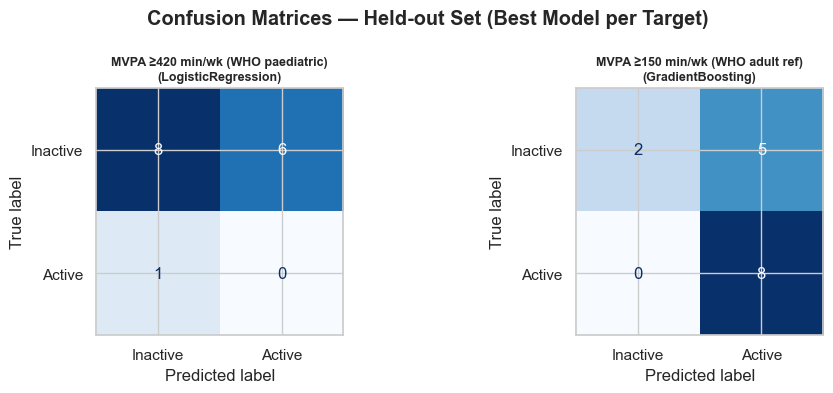

In [32]:
if len(ho_df) > 0:
    tgt_keys = [t for t in TARGETS.keys() if f'next_{t}' in holdout_df.columns]
    n_tgts = len(tgt_keys)
    fig, axes = plt.subplots(1, n_tgts, figsize=(5 * n_tgts, 4))
    if n_tgts == 1:
        axes = [axes]

    for ax, tgt_name in zip(axes, tgt_keys):
        col    = f'next_{tgt_name}'
        best_m = ho_df[ho_df['tgt_key'] == tgt_name].sort_values('roc_auc', ascending=False).iloc[0]['model']
        model  = MODELS.get(best_m, list(MODELS.values())[0])

        avail   = [f for f in feature_list if f in train_df.columns and f in holdout_df.columns]
        tr_sub  = train_df.dropna(subset=[col])
        ho_sub  = holdout_df.dropna(subset=[col])

        model.fit(tr_sub[avail].values, tr_sub[col].astype(int).values)
        y_pred = model.predict(ho_sub[avail].values)

        cm = confusion_matrix(ho_sub[col].astype(int).values, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{TARGETS[tgt_name]["label"]}\n({best_m})', fontsize=9, fontweight='bold')

    plt.suptitle('Confusion Matrices — Held-out Set (Best Model per Target)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=120, bbox_inches='tight')
    plt.show()

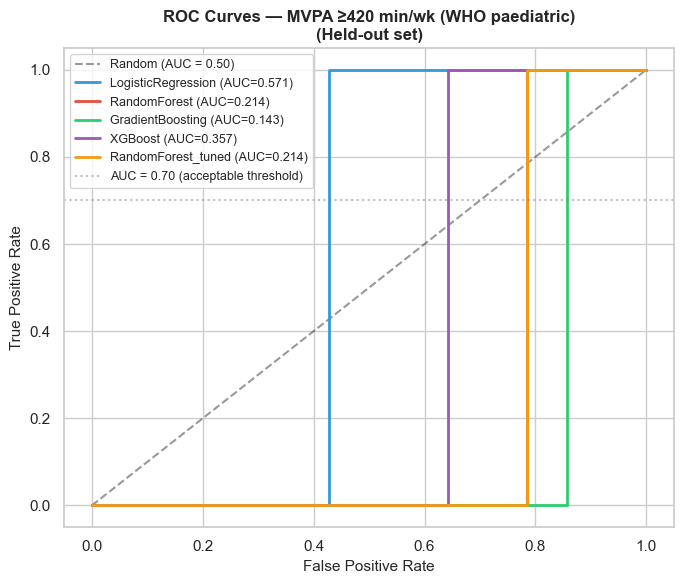

In [33]:
target_col = f'next_{PRIMARY_TARGET}'
tr_sub  = train_df.dropna(subset=[target_col]).copy()
ho_sub  = holdout_df.dropna(subset=[target_col]).copy()
avail   = [f for f in feature_list if f in tr_sub.columns and f in ho_sub.columns]

if len(ho_sub) > 5 and ho_sub[target_col].nunique() == 2:
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.50)')

    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
    for (model_name, model), color in zip(MODELS.items(), colors):
        model.fit(tr_sub[avail].values, tr_sub[target_col].astype(int).values)
        y_prob = model.predict_proba(ho_sub[avail].values)[:, 1]
        try:
            auc = roc_auc_score(ho_sub[target_col].astype(int).values, y_prob)
            fpr, tpr, _ = roc_curve(ho_sub[target_col].astype(int).values, y_prob)
            ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{model_name} (AUC={auc:.3f})')
        except:
            pass

    ax.axhline(0.70, color='grey', linestyle=':', alpha=0.5, label='AUC = 0.70 (acceptable threshold)')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curves — {TARGETS[PRIMARY_TARGET]["label"]}\n(Held-out set)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Insufficient held-out data for ROC curve — check hold-out split.')

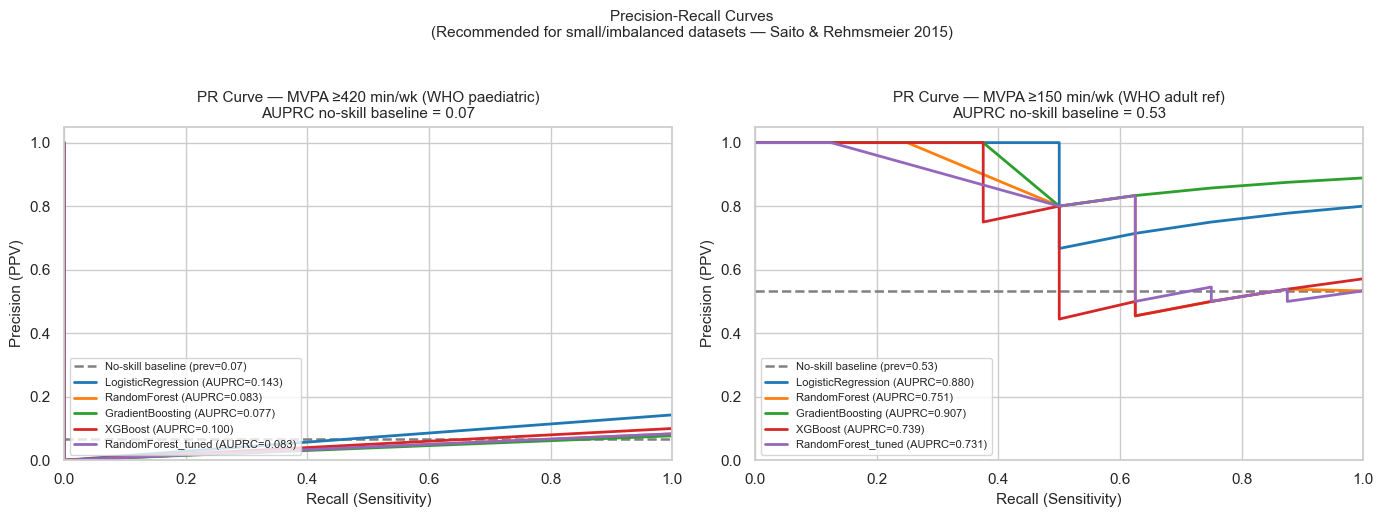

PR curve plot saved → results_thesis/prc_curves.png

=== AUPRC Lift over No-Skill Baseline ===
  Target                          Baseline  Best AUPRC    Lift
  ------------------------------------------------------------
  MVPA ≥420 min/wk (WHO paediatric)     0.067       0.143  +0.076
  MVPA ≥150 min/wk (WHO adult ref)     0.533       0.907  +0.373

  Lift > 0 means the best model adds value beyond random guessing.
  For mvpa_420, even small positive lift at N=12 patients is noteworthy.


In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tgt_name, cfg) in zip(axes, TARGETS.items()):
    y_true_prc = ho_labels.get(tgt_name)
    if y_true_prc is None:
        ax.set_title(f'{cfg["label"]}\n(skipped — insufficient hold-out data)')
        continue

    prevalence = y_true_prc.mean()
    ax.axhline(prevalence, linestyle='--', color='grey', linewidth=1.8,
               label=f'No-skill baseline (prev={prevalence:.2f})')

    colors = plt.cm.tab10.colors
    model_probas = ho_probas.get(tgt_name, {})
    for j, (model_name, y_prob_prc) in enumerate(model_probas.items()):
        try:
            ap = average_precision_score(y_true_prc, y_prob_prc)
            prec, rec, _ = precision_recall_curve(y_true_prc, y_prob_prc)
            ax.plot(rec, prec, color=colors[j % 10], linewidth=2,
                    label=f'{model_name} (AUPRC={ap:.3f})')
        except Exception:
            pass

    ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
    ax.set_ylabel('Precision (PPV)', fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_title(f'PR Curve — {cfg["label"]}\nAUPRC no-skill baseline = {prevalence:.2f}', fontsize=11)
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Precision-Recall Curves\n'             '(Recommended for small/imbalanced datasets — Saito & Rehmsmeier 2015)',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('PR curve plot saved → results_thesis/prc_curves.png')
print()

print('=== AUPRC Lift over No-Skill Baseline ===')
print(f'  {"Target":<30} {"Baseline":>9} {"Best AUPRC":>11} {"Lift":>7}')
print(f'  {"-"*60}')
for tgt_name, cfg in TARGETS.items():
    y_true_prc = ho_labels.get(tgt_name)
    model_probas = ho_probas.get(tgt_name, {})
    if y_true_prc is None or not model_probas:
        continue
    baseline = y_true_prc.mean()
    aps = []
    for y_prob_prc in model_probas.values():
        try:
            aps.append(average_precision_score(y_true_prc, y_prob_prc))
        except Exception:
            pass
    if aps:
        best_ap = max(aps)
        lift = best_ap - baseline
        print(f'  {cfg["label"]:<30} {baseline:>9.3f} {best_ap:>11.3f} {lift:>+7.3f}')
print()
print('  Lift > 0 means the best model adds value beyond random guessing.')
print('  For mvpa_420, even small positive lift at N=12 patients is noteworthy.')


In [35]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """ECE with equal-width bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_rows = []
    n = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        avg_pred = y_prob[mask].mean()
        avg_true = y_true[mask].mean()
        weight   = mask.sum() / n
        ece += weight * abs(avg_pred - avg_true)
        bin_rows.append((f'{lo:.1f}–{hi:.1f}', mask.sum(), avg_pred, avg_true, abs(avg_pred - avg_true)))
    return ece, bin_rows

print('=== Probability Calibration Analysis (Expected Calibration Error) ===')
print()
print('  A well-calibrated model: when it predicts P=0.7, 70% of those weeks are truly active.')
print('  ECE = 0.00 → perfect calibration | ECE = 0.50 → completely miscalibrated.')
print()

for tgt_name, cfg in TARGETS.items():
    y_true_cal = ho_labels.get(tgt_name)
    model_probas_cal = ho_probas.get(tgt_name, {})
    if y_true_cal is None or not model_probas_cal:
        continue

    print(f'  ── {cfg["label"]} ──')
    print(f'  {"Model":<25} {"ECE":>7}  Calibration quality')
    print(f'  {"-"*55}')
    for model_name, y_prob_cal in model_probas_cal.items():
        ece, _ = expected_calibration_error(y_true_cal, y_prob_cal)
        qual = 'excellent (≤0.10)' if ece <= 0.10 else ('acceptable (≤0.20)' if ece <= 0.20 else 'POOR — overconfident')
        print(f'  {model_name:<25} {ece:>7.3f}  {qual}')
    print()

best_model_name = ho_df[ho_df['tgt_key'] == PRIMARY_TARGET].sort_values('roc_auc', ascending=False).iloc[0]['model']
y_true_cal = ho_labels.get(PRIMARY_TARGET)
if y_true_cal is not None and PRIMARY_TARGET in ho_probas and best_model_name in ho_probas[PRIMARY_TARGET]:
    y_prob_best = ho_probas[PRIMARY_TARGET][best_model_name]
    ece_best, bin_rows_best = expected_calibration_error(y_true_cal, y_prob_best)
    print(f'  === Calibration detail: {best_model_name} on {PRIMARY_TARGET} ===')
    print(f'  {"Prob bin":>12}  {"N weeks":>8}  {"Pred prob":>10}  {"Actual %":>9}  {"Gap":>7}')
    print(f'  {"-"*55}')
    for bin_label, n_bin, avg_pred, avg_true, gap in bin_rows_best:
        print(f'  {bin_label:>12}  {n_bin:>8}  {avg_pred:>10.3f}  {avg_true:>9.3f}  {gap:>7.3f}')
    print()
    print(f'  Overall ECE: {ece_best:.3f}')
    print()
    if ece_best > 0.20:
        print('  ⚠  POOR calibration — the model is overconfident.')
        print(f'     Bimodal predictions (near 0 or near 1) with ECE={ece_best:.3f} confirm')
        print('     the model has learned to strongly commit to patient-level profiles')
        print('     rather than producing calibrated weekly risk estimates.')
        print('     RECOMMENDATION: Apply Platt scaling (logistic calibration) in a')
        print('     future study with ≥30 patients to produce reliable probability scores')
        print('     suitable for clinical decision support.')


=== Probability Calibration Analysis (Expected Calibration Error) ===

  A well-calibrated model: when it predicts P=0.7, 70% of those weeks are truly active.
  ECE = 0.00 → perfect calibration | ECE = 0.50 → completely miscalibrated.

  ── MVPA ≥420 min/wk (WHO paediatric) ──
  Model                         ECE  Calibration quality
  -------------------------------------------------------
  LogisticRegression          0.466  POOR — overconfident
  RandomForest                0.515  POOR — overconfident
  GradientBoosting            0.693  POOR — overconfident
  XGBoost                     0.506  POOR — overconfident
  RandomForest_tuned          0.507  POOR — overconfident

  ── MVPA ≥150 min/wk (WHO adult ref) ──
  Model                         ECE  Calibration quality
  -------------------------------------------------------
  LogisticRegression          0.216  POOR — overconfident
  RandomForest                0.337  POOR — overconfident
  GradientBoosting            0.320  POOR — 

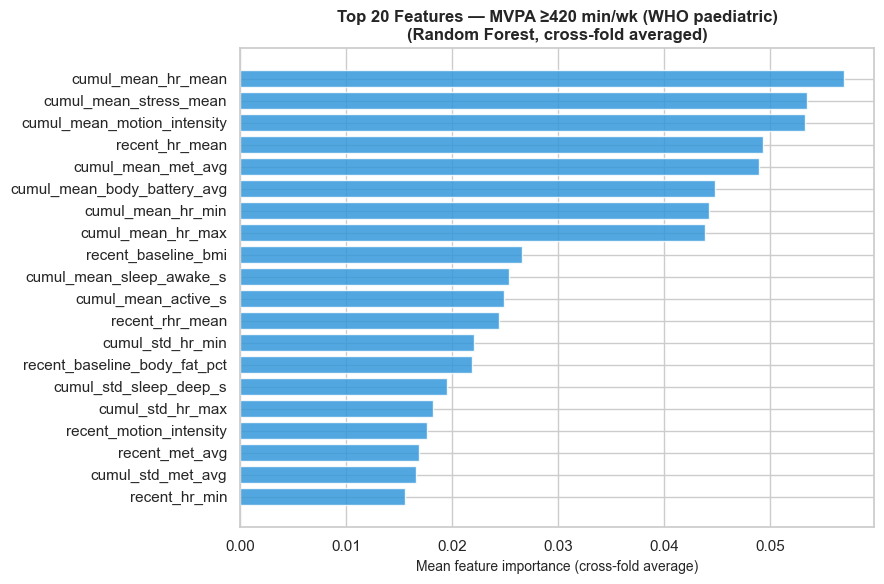

Top 10 features for mvpa_420:
                    feature  importance
         cumul_mean_hr_mean    0.056977
     cumul_mean_stress_mean    0.053455
cumul_mean_motion_intensity    0.053305
             recent_hr_mean    0.049312
         cumul_mean_met_avg    0.048967
cumul_mean_body_battery_avg    0.044832
          cumul_mean_hr_min    0.044222
          cumul_mean_hr_max    0.043855
        recent_baseline_bmi    0.026574
   cumul_mean_sleep_awake_s    0.025348


In [36]:

def borda_rank(score_arrays, feature_names):
    """Average fold importances, then rank by Borda count."""
    if not score_arrays:
        return pd.DataFrame()
    avg_imp = np.mean(score_arrays, axis=0)
    return pd.DataFrame({'feature': feature_names, 'importance': avg_imp})\
             .sort_values('importance', ascending=False).reset_index(drop=True)

best_tree_key = next(
    (k for k in fold_importances if k.startswith(PRIMARY_TARGET) and 'RandomForest' in k), None
)

if best_tree_key:
    imp_data = fold_importances[best_tree_key]
    imp_df = borda_rank(imp_data['importances'], imp_data['features'])
    top_n = 20

    fig, ax = plt.subplots(figsize=(9, 6))
    top = imp_df.head(top_n)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            color='#3498db', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Mean feature importance (cross-fold average)', fontsize=10)
    ax.set_title(f'Top {top_n} Features — {TARGETS[PRIMARY_TARGET]["label"]}\n(Random Forest, cross-fold averaged)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f'Top 10 features for {PRIMARY_TARGET}:')
    print(imp_df.head(10).to_string(index=False))
    imp_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
else:
    print('Feature importances not available — CV may not have completed for primary target.')

## 3.4 Results Summary

Prints a consolidated summary of held-out performance, feature importance rankings, and dataset statistics.

In [37]:
AUC_THRESHOLD = 0.70   # Hosmer & Lemeshow (2000) — minimum acceptable discrimination

print('=' * 65)
print('  eBATTLE THESIS ANALYSIS — SUMMARY REPORT')
print('=' * 65)
print(f'  Dataset        : {len(raw):,} raw rows → {len(model_df):,} user-weeks')
_n_panel  = panel['user_id'].nunique()
_n_model  = model_df['user_id'].nunique()
_n_excl_b = _n_panel - _n_model
print(f'  Patients       : {_n_panel} panel  |  {_n_excl_b} excluded (< {MIN_VALID_DAYS} wear-days/wk or < 2 qualifying weeks)')
print(f'                   {_n_model} model-eligible  |  {len(train_users)} train  |  {len(holdout_users)} held-out')
print(f'  Features       : {len(feature_list)} (after missingness + correlation filter)')
print(f'  Targets        : {list(TARGETS.keys())}')
print(f'  Primary target : {PRIMARY_TARGET}')
print(f'  Models         : {list(MODELS.keys())}')
print(f'  CV strategy    : StratifiedGroupKFold ({CV_FOLDS} folds, grouped by user_id)')
print()

if len(ho_df) > 0:
    best_overall = ho_df.sort_values('roc_auc', ascending=False).iloc[0]
    print(f'  Best overall   : {best_overall["model"]} on {best_overall["target"]}  (AUC={best_overall["roc_auc"]:.3f})')
    print()
    print('  ── H₀ Result per Target ────────────────────────────────────────────')
    for tgt in TARGETS:
        sub = ho_df[ho_df['tgt_key'] == tgt]
        if sub.empty:
            continue
        best_auc   = sub['roc_auc'].max()
        best_model = sub.sort_values('roc_auc', ascending=False).iloc[0]['model']
        rejected   = best_auc >= AUC_THRESHOLD
        note = '  [⚠ 82% class imbalance — AUC inflated by majority class]' if tgt == 'mvpa_150' else ''
        print(f'  {tgt:<12}: AUC={best_auc:.3f}  H₀ rejected? {"YES" if rejected else "NO "}  (best: {best_model}){note}')

    print()
    primary_auc = ho_df[ho_df['tgt_key'] == PRIMARY_TARGET]['roc_auc'].max()
    if primary_auc < AUC_THRESHOLD:
        print(f'  ┌─ PRIMARY CONCLUSION ────────────────────────────────────────┐')
        print(f'  │  H₀ NOT rejected for {PRIMARY_TARGET}                           │')
        print(f'  │  AUC = {primary_auc:.3f} < {AUC_THRESHOLD} — pilot data insufficient to detect    │')
        print(f'  │  a predictive signal for paediatric PA adherence.        │')
        print(f'  └──────────────────────────────────────────────────────────┘')
    else:
        print(f'  PRIMARY CONCLUSION: H₀ rejected for {PRIMARY_TARGET} (AUC={primary_auc:.3f})')

print()
print(f'  Outputs saved to: {OUTPUT_DIR}')
print('=' * 65)


  eBATTLE THESIS ANALYSIS — SUMMARY REPORT
  Dataset        : 20,440 raw rows → 150 user-weeks
  Patients       : 17 panel  |  5 excluded (< 3 wear-days/wk or < 2 qualifying weeks)
                   12 model-eligible  |  9 train  |  3 held-out
  Features       : 80 (after missingness + correlation filter)
  Targets        : ['mvpa_420', 'mvpa_150']
  Primary target : mvpa_420
  Models         : ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'RandomForest_tuned']
  CV strategy    : StratifiedGroupKFold (3 folds, grouped by user_id)

  Best overall   : GradientBoosting on MVPA ≥150 min/wk (WHO adult ref)  (AUC=0.920)

  ── H₀ Result per Target ────────────────────────────────────────────
  mvpa_420    : AUC=0.571  H₀ rejected? NO   (best: LogisticRegression)
  mvpa_150    : AUC=0.920  H₀ rejected? YES  (best: GradientBoosting)  [⚠ 82% class imbalance — AUC inflated by majority class]

  ┌─ PRIMARY CONCLUSION ────────────────────────────────────────┐
  │  H₀ NOT re